# Impact of socio-economic factors on real estate prices in New York City

## Introduction

Real estate prices in New York City are influenced by a complex interplay of geographic, economic, and social variables. This analysis shows the socio-economic status (SES) of the population and property market values. While location is always important, we can now use data to look deeper into each neighborhood.
By combining real estate transaction data with US Census demographics, this study moves beyond traditional property valuation. We aim to understand why certain areas have higher prices by exploring how variables such as income, professional employment, and commute act as the primary drivers of real estate pricing. We will analyze these trends across all five boroughs: Manhattan, The Bronx, Brooklyn, Queens, and Staten Island.

## Data integration and methodology
To achieve a comprehensive analysis this study merges two datasets:
1. NYC Sales Dataset 2016-2017. It containing transaction prices, property types, and geographical identifiers.
2. US Census Data 2013-2017. It providing demographic and socio-economic metrics at the census tract level.
The connection between these datasets is facilitated through the **Geographic Correspondence** engine allowing us to map census tracts to ZIP codes (ZCTAs) for a precise merge.

**Temporal Alignment (ACS 2017)** \
I use the **ACS 2017 5-year estimates** for the socio-economic part. Even though the property sales data covers a specific period September 2016 - September 2017, the government doesn't publish monthly population data for small neighborhoods. However neighborhood characteristics like income and professional status don't change drastically in a few months. Therefore the 2017 dataset provides a perfect basis for undestanding of the conditions at the time these properties were being sold.

## Analytical framework
The research follows a clear step-by-step process:
1. Data preprocessing \
Cleaning and merging datasets to ensure integrity and alignment. А key step here is Log transformation to handle the right-skewed nature of real estate prices:
$$ \ln(P) = \text{log\_sale\_price} $$

3. Exploratory Data Analysis (EDA) \
Using histograms and scatter plots to visualize trends and relationships. We also use the Pearson correlation coefficient (***r***) to measure the strength and direction of the linear relationship between socio-economic variables and property prices:
$$ r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}} $$

5. Statistical validation \
Applying Levene’s test to check for homogeneity of variance (homoscedasticity):
$$ H_0: \sigma_1^2 = \sigma_2^2 = \dots = \sigma_k^2 $$
We also use Q-Q plots to verify if our log-transformed data follows a normal distribution.

6. Hypothesis testing \
We use Two-Way ANOVA to see if the Borough and Tax group have a real impact on prices. This is measured by the F-statistic, which compares the differences between groups to the variation within them: Utilizing T-tests and two-way ANOVA to determine how different factors affect the price. 
$$ F = \frac{\text{Variance between boroughs}}{\text{Variance within boroughs}} $$
A high F-value will prove that location and building type are significant drivers of the NYC real estate market. We also use independent T-tests to compare specific pairs of boroughs. This helps us see if the price difference between two areas is statistically significant
county_to_borough = {
    'New York County': 'Manhattan',
    'Kings County': 'Brooklyn',
    'Queens County': 'Queens',
    'Bronx County': 'Bronx',
    'Richmond County': 'Staten Island'
}
7. Bayesian inference \
We use Bayes' theorem to calculate probabilities. For example, if we know a property is "Elite" (in the top 10% of the market), we calculate the probability that it is located in a specific borough:
$$ P(\text{Borough} | \text{Elite}) = \frac{P(\text{Elite} | \text{Borough}) \cdot P(\text{Borough})}{P(\text{Elite})} $$

8. Fourier аnalysis \
We use the Fourier transform to see if the housing market follows any waves or cycles (seasonality) over time:
$$ \hat{f}(\xi) = \int_{-\infty}^{\infty} f(x) e^{-2\pi i x \xi} dx $$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns

## 1. Data cleaning of first dataset - NYC property sales

In [2]:
nyc_dataset = pd.read_csv("nyc-rolling-sales.csv")

In [3]:
nyc_dataset

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84543,8409,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7349,34,,B9,37 QUAIL LANE,...,2,0,2,2400,2575,1998,1,B9,450000,2016-11-28 00:00:00
84544,8410,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7349,78,,B9,32 PHEASANT LANE,...,2,0,2,2498,2377,1998,1,B9,550000,2017-04-21 00:00:00
84545,8411,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7351,60,,B2,49 PITNEY AVENUE,...,2,0,2,4000,1496,1925,1,B2,460000,2017-07-05 00:00:00
84546,8412,5,WOODROW,22 STORE BUILDINGS,4,7100,28,,K6,2730 ARTHUR KILL ROAD,...,0,7,7,208033,64117,2001,4,K6,11693337,2016-12-21 00:00:00


In [4]:
nyc_dataset.head()

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00


In [5]:
nyc_dataset.dtypes

Unnamed: 0                         int64
BOROUGH                            int64
NEIGHBORHOOD                      object
BUILDING CLASS CATEGORY           object
TAX CLASS AT PRESENT              object
BLOCK                              int64
LOT                                int64
EASE-MENT                         object
BUILDING CLASS AT PRESENT         object
ADDRESS                           object
APARTMENT NUMBER                  object
ZIP CODE                           int64
RESIDENTIAL UNITS                  int64
COMMERCIAL UNITS                   int64
TOTAL UNITS                        int64
LAND SQUARE FEET                  object
GROSS SQUARE FEET                 object
YEAR BUILT                         int64
TAX CLASS AT TIME OF SALE          int64
BUILDING CLASS AT TIME OF SALE    object
SALE PRICE                        object
SALE DATE                         object
dtype: object

In [6]:
nyc_dataset.shape

(84548, 22)

In [7]:
nyc_dataset.columns = nyc_dataset.columns.str.lower().str.replace(' ', '_')

In [8]:
nyc_dataset['unnamed:_0']

0           4
1           5
2           6
3           7
4           8
         ... 
84543    8409
84544    8410
84545    8411
84546    8412
84547    8413
Name: unnamed:_0, Length: 84548, dtype: int64

In [9]:
nyc_dataset.drop(columns = ['unnamed:_0'], inplace = True)

In [10]:
nyc_dataset.shape

(84548, 21)

In [11]:
nyc_dataset.isnull().sum()

borough                           0
neighborhood                      0
building_class_category           0
tax_class_at_present              0
block                             0
lot                               0
ease-ment                         0
building_class_at_present         0
address                           0
apartment_number                  0
zip_code                          0
residential_units                 0
commercial_units                  0
total_units                       0
land_square_feet                  0
gross_square_feet                 0
year_built                        0
tax_class_at_time_of_sale         0
building_class_at_time_of_sale    0
sale_price                        0
sale_date                         0
dtype: int64

Some cells maybe contain spaces or dashes ('-') instead of being empty. We need replace them with NaN values to reveal the count of an actual missing data.

In [12]:
nyc_dataset = nyc_dataset.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [13]:
pd.set_option('future.no_silent_downcasting', True)

In [14]:
nyc_dataset.replace(['-', '', ' '], np.nan, inplace = True)

I set the ***future.no_silent_downcasting*** option to True. This ensures the code remains compatible with future versions of Pandas and prevents unnecessary warning messages when replacing values.

In [15]:
nyc_dataset = nyc_dataset.infer_objects(copy=False)

In [16]:
print(nyc_dataset.isnull().sum())

borough                               0
neighborhood                          0
building_class_category               0
tax_class_at_present                738
block                                 0
lot                                   0
ease-ment                         84548
building_class_at_present           738
address                               0
apartment_number                  65496
zip_code                              0
residential_units                     0
commercial_units                      0
total_units                           0
land_square_feet                  26252
gross_square_feet                 27612
year_built                            0
tax_class_at_time_of_sale             0
building_class_at_time_of_sale        0
sale_price                        14561
sale_date                             0
dtype: int64


The columns ***land_square_feet***, ***gross_square_feet***, and ***sale_price*** are currently stored as objects. We need to convert them to numeric types to perform mathematical operations, such as calculating averages or analyzing price trends.

In [17]:
num_cols = ['land_square_feet', 'gross_square_feet', 'sale_price']
for col in num_cols:
    nyc_dataset[col] = pd.to_numeric(nyc_dataset[col], errors = 'coerce')

In [18]:
nyc_dataset.dtypes

borough                             int64
neighborhood                       object
building_class_category            object
tax_class_at_present               object
block                               int64
lot                                 int64
ease-ment                         float64
building_class_at_present          object
address                            object
apartment_number                   object
zip_code                            int64
residential_units                   int64
commercial_units                    int64
total_units                         int64
land_square_feet                  float64
gross_square_feet                 float64
year_built                          int64
tax_class_at_time_of_sale           int64
building_class_at_time_of_sale     object
sale_price                        float64
sale_date                          object
dtype: object

In [19]:
nyc_dataset.sale_price

0         6625000.0
1               NaN
2               NaN
3         3936272.0
4         8000000.0
            ...    
84543      450000.0
84544      550000.0
84545      460000.0
84546    11693337.0
84547       69300.0
Name: sale_price, Length: 84548, dtype: float64

Deleting invalid price values -> ***sale_price < 10 000 & sale_price = 0***, because these values are not real sales. They are inherited estates or business sales. They don't have analytical value for our purpose. Also deleting NaN values, as they would distort with our calculations and could lead to biased or incorrect statistical results.

In [20]:
nyc_dataset.dropna(subset = ['sale_price'], inplace = True)

In [21]:
nyc_dataset.sale_price.isnull().sum()

np.int64(0)

In [22]:
(nyc_dataset.sale_price == 0).sum()

np.int64(10228)

In [23]:
(nyc_dataset.sale_price < 1000).sum()

np.int64(11306)

In [24]:
nyc_dataset = nyc_dataset[nyc_dataset.sale_price >= 10000].copy()

In [25]:
nyc_dataset.shape

(58465, 21)

There are residential and commerce buildings. For our analysis we need residential buildings. We need to remove other. For that purpose we can filter the data with ***tax_building_at_sale_price*** to remove business deals.
#### NYC Property Tax Classes
Class 1 - 1-3 Unit residential: 1- to 3-family homes, small condos, and vacant land zoned residential. These are generally assessed at a lower percentage of market value (6%). \
Class 2 - Apartments & co-ops: Rental apartment buildings, cooperatives, and condominiums with 4 or more units. \
Class 3 - Utility properties: Property owned by utility companies, including special franchise property. \
Class 4 - Commercial & industrial: Office buildings, factories, retail space, and warehouses.

In [26]:
nyc_dataset = nyc_dataset[nyc_dataset['tax_class_at_time_of_sale'].isin([1, 2])].copy()

To ensure our analysis focuses strictly on residential homes we will remove properties that contain any commercial units. This helps us avoid price distortions caused by business.

In [27]:
nyc_dataset = nyc_dataset[nyc_dataset['commercial_units'] == 0]

In [28]:
print(nyc_dataset['commercial_units'].unique())

[0]


In [29]:
(nyc_dataset['total_units'] == 0).sum()

np.int64(16128)

When an individual apartment in a Co-op building is sold, the city often records "0 units" for that specific transaction. This is because the buyer is technically purchasing shares in a corporation that owns the whole building, rather than a separate deed for a physical unit. \
While the *total_units* column shows 0, the *sale price* and *location* are accurate and represent the market value of a single residential living space.
Analytical Decision: I have treated these "0 unit" records as single-family residential sales for the purpose of price analysis. Excluding them would remove over 25,000 valid apartment sales, significantly underrepresenting the Manhattan and Brooklyn markets.

Properties with more than three units are typically commercial investments rather than individual homes. To better analyze factors affecting the average person, we have restricted the dataset to properties with 3 units or fewer. This ensures that institutional investments do not skew our findings

In [30]:
nyc_dataset = nyc_dataset[nyc_dataset.total_units <= 3].copy()

In [31]:
len(nyc_dataset)

52962

In [32]:
(nyc_dataset['total_units'] == 0).sum()

np.int64(16128)

In [33]:
pd.qcut(nyc_dataset['sale_price'], 10).value_counts().sort_index()

sale_price
(9999.999, 225000.0]       5360
(225000.0, 330000.0]       5356
(330000.0, 425000.0]       5322
(425000.0, 510000.0]       5229
(510000.0, 612000.0]       5219
(612000.0, 730000.0]       5408
(730000.0, 880000.0]       5205
(880000.0, 1155000.0]      5273
(1155000.0, 1817950.0]     5293
(1817950.0, 98525704.0]    5297
Name: count, dtype: int64

In [34]:
nyc_dataset.shape

(52962, 21)

In [35]:
top_20_expensive = nyc_dataset.sort_values(by='sale_price', ascending=False).iloc[0:20]

In [36]:
top_20_expensive[['borough', 'neighborhood', 'total_units', 'residential_units', 'sale_price']]

,borough,neighborhood,total_units,residential_units,sale_price
15983,1,UPPER WEST SIDE (59-79),1,1,98525704.0
7387,1,MIDTOWN CBD,1,1,87660898.0
7383,1,MIDTOWN CBD,1,1,65661755.0
7381,1,MIDTOWN CBD,1,1,65163580.0
17166,1,UPPER WEST SIDE (79-96),1,1,61250000.0
7386,1,MIDTOWN CBD,1,1,60893873.0
11979,1,UPPER EAST SIDE (59-79),0,0,55000000.0
15589,1,UPPER WEST SIDE (59-79),1,1,50550000.0
1399,1,CIVIC CENTER,1,1,47866945.0
9156,1,MIDTOWN WEST,1,1,45824750.0


Refining the dataset to focus on individual residential sales. By selecting Tax Classes 1 and 2 and limiting the properties to 3 units or fewer, we exclude large-scale commercial investments and massive apartment complexes. This leaves us with 53,665 records representing the primary housing market. High-value outliers (up to $98M) are intentionally retained at this stage to observe the full diversity of the NYC luxury sector before final statistical normalization.

The column ease-ment contains no useful information, it is entirely empty, so we are removing it from the dataset.

In [37]:
nyc_dataset = nyc_dataset.drop(columns=['ease-ment']).copy()

The column apartment_number is missing more than 70% of its data. Since it doesn't provide significant value, we have decided to remove it.

In [38]:
nyc_dataset = nyc_dataset.drop(columns = ['apartment_number']).copy()

In [39]:
nyc_dataset['building_class_at_time_of_sale'].value_counts()

building_class_at_time_of_sale
D4    11272
R4    10264
A1     4719
A5     4051
B2     3177
B1     2762
B3     2493
C6     2482
C0     2307
A2     1950
R9     1109
R3     1097
R1     1033
A9      989
B9      955
R2      658
V0      475
A0      283
A3      241
D0      207
R6      149
A4      137
A6       74
G0       39
RR       10
A7        8
Z0        6
C8        6
C3        4
R8        2
V2        1
R0        1
V3        1
Name: count, dtype: int64

We identified several types of properties that do not fit the goal of analyzing the residential housing market.
* V0, V2, V3 are vacant land. These are empty plots with no buildings. Since there is no living space, they can't be compared with residential property prices.
* G0 are residential garages. While they are located in residential areas they are not homes and their prices follow different market rules.
* Z0 are miscellaneous. These are other structures (sheds, storage, etc.) that are not residential units.
  We decided to remove these building class categories in order not to skew our data.

Removing these records allows the model to focus exclusively on actual homes - apartments and houses, leading to a much stronger correlation with socio-economic factors like income and education.

Other building classes are: 
* A - one-family dwelling (house)
* B - two-family dwellings
* C - three-family dwellings
* D4 - co-ops with elevator
* R4 - condos with elevator

In [40]:
nyc_dataset = nyc_dataset[~nyc_dataset['building_class_at_time_of_sale'].isin(['V0', 'V2', 'V3', 'G0', 'Z0'])]

In [41]:
print(nyc_dataset['building_class_at_time_of_sale'].value_counts())

building_class_at_time_of_sale
D4    11272
R4    10264
A1     4719
A5     4051
B2     3177
B1     2762
B3     2493
C6     2482
C0     2307
A2     1950
R9     1109
R3     1097
R1     1033
A9      989
B9      955
R2      658
A0      283
A3      241
D0      207
R6      149
A4      137
A6       74
RR       10
A7        8
C8        6
C3        4
R8        2
R0        1
Name: count, dtype: int64


In [42]:
nyc_dataset['building_class_category'].value_counts()

building_class_category
01 ONE FAMILY DWELLINGS                       12452
10 COOPS - ELEVATOR APARTMENTS                11479
13 CONDOS - ELEVATOR APARTMENTS               10264
02 TWO FAMILY DWELLINGS                        9387
09 COOPS - WALKUP APARTMENTS                   2488
03 THREE FAMILY DWELLINGS                      2307
04 TAX CLASS 1 CONDOS                          1246
17 CONDO COOPS                                 1109
15 CONDOS - 2-10 UNIT RESIDENTIAL              1033
12 CONDOS - WALKUP APARTMENTS                   658
11A CONDO-RENTALS                                10
07 RENTALS - WALKUP APARTMENTS                    4
16 CONDOS - 2-10 UNIT WITH COMMERCIAL UNIT        2
11 SPECIAL CONDO BILLING LOTS                     1
Name: count, dtype: int64

In [43]:
(nyc_dataset.land_square_feet == 0).sum()

np.int64(7784)

In [44]:
nyc_dataset.gross_square_feet.isna().sum()

np.int64(20622)

In [45]:
nyc_dataset['gross_square_feet'] = nyc_dataset['gross_square_feet'].replace(0, np.nan)

In [46]:
nyc_dataset.gross_square_feet.isna().sum()

np.int64(28431)

In [47]:
nyc_dataset[nyc_dataset['gross_square_feet'].isna()]['tax_class_at_time_of_sale'].value_counts()

tax_class_at_time_of_sale
2    27043
1     1388
Name: count, dtype: int64

In [48]:
nyc_dataset.loc[(nyc_dataset['tax_class_at_time_of_sale'] == 1) & (nyc_dataset['gross_square_feet'].isna()), 'sale_price'].describe()

count    1.388000e+03
mean     5.903147e+05
std      5.819271e+05
min      1.000000e+04
25%      3.200000e+05
50%      4.500070e+05
75%      6.682500e+05
max      1.360000e+07
Name: sale_price, dtype: float64

In [49]:
nyc_dataset.loc[(nyc_dataset['tax_class_at_time_of_sale'] == 1) & (nyc_dataset['gross_square_feet'].isna()), ['neighborhood', 'sale_price', 'year_built', 'building_class_category']].sort_values('sale_price')

,neighborhood,sale_price,year_built,building_class_category
46231,SHEEPSHEAD BAY,10000.0,2005,04 TAX CLASS 1 CONDOS
33658,COBBLE HILL-WEST,13912.0,0,04 TAX CLASS 1 CONDOS
33657,COBBLE HILL-WEST,13912.0,0,04 TAX CLASS 1 CONDOS
23914,SOUNDVIEW,16000.0,2008,04 TAX CLASS 1 CONDOS
67760,OAKLAND GARDENS,19449.0,0,04 TAX CLASS 1 CONDOS
...,...,...,...,...
16524,UPPER WEST SIDE (79-96),3195000.0,0,04 TAX CLASS 1 CONDOS
32988,CARROLL GARDENS,3229200.0,2015,04 TAX CLASS 1 CONDOS
7041,MANHATTAN VALLEY,4454843.0,1905,04 TAX CLASS 1 CONDOS
24392,THROGS NECK,5000000.0,2002,04 TAX CLASS 1 CONDOS


Filling missing values in column ***gross_square_feet*** using the median value for each specific neighborhood. The median is preferred over the mean because real estate data is often skewed by extreme outliers like very large or very small properties.This gives us a more realistic view of a typical property and prevents our analysis from being distorted.

In [50]:
nyc_dataset['price_tier'] = nyc_dataset.groupby('borough')['sale_price'].transform(
    lambda x: pd.qcut(x, 3, labels=['Low', 'Medium', 'High']))

In [51]:
medians_tax1 = nyc_dataset[
    (nyc_dataset['tax_class_at_time_of_sale'] == 1) & 
    (nyc_dataset['gross_square_feet'].notnull())
].groupby(['borough', 'price_tier'], observed=True)['gross_square_feet'].median()

In [52]:
def fill_sqft_refined_tax1(row):
    if pd.isnull(row['gross_square_feet']) and row['tax_class_at_time_of_sale'] == 1:
        return medians_tax1.get((row['borough'], row['price_tier']), np.nan)
    return row['gross_square_feet']

In [53]:
nyc_dataset['gross_square_feet'] = nyc_dataset.apply(fill_sqft_refined_tax1, axis=1)

In [54]:
print(f"Zero sqrt - tax class 1: {nyc_dataset[nyc_dataset['tax_class_at_time_of_sale'] == 1]['gross_square_feet'].isna().sum()}")
print(f"Zero sqrt - tax class 2: {nyc_dataset[nyc_dataset['tax_class_at_time_of_sale'] == 2]['gross_square_feet'].isna().sum()}")

Zero sqrt - tax class 1: 0
Zero sqrt - tax class 2: 27043


For the 1388 records where square footage was missing we treated this as a statistical anomaly rather than a systemic rule because in New York City, houses with tax class 1 are required by law to have their square footage recorded for tax assessments. To fix this without losing data we used **price tier imputation**:
1. We divided properties into three price groups - low, medium, high for each **borough**.
2. Calculated the median square footage for each group using only Tax class 1 properties with existing data.
3. Filled the missing values using these medians to ensure a realistic relationship between price and size (e.g., a 13 mln property receives a larger area than a 100K property). \

We dont fill the missing data for these 27 043 records. In NYC co-ops represent shares in a corporation rather than physical land, and their square footage is systematically not recorded in this dataset. Filling them with "average" numbers would create false data and skew the final analysis.

In [55]:
nyc_dataset.land_square_feet.isnull().sum()

np.int64(20506)

Following the methodology of the NYC Department of finance and REBNY, the 'Price per Square Foot' is calculated using **gross square feet**. This approach allows for a consistent comparison between houses (tax class 1) and apartments (tax class 2), where the land value is implicitly included in the location premium of the sale price.

In [56]:
nyc_dataset['land_square_feet'] = nyc_dataset['land_square_feet'].replace(0, np.nan)

In [57]:
nyc_dataset.land_square_feet.isnull().sum()

np.int64(28290)

We have decided not to impute the missing values for this column. In NYC particularly for apartments (Tax Class 2), land ownership is collective and not assigned to individual units. Therefore, filling these gaps with estimated numbers would introduce artificial noise. The missing data is treated as a structural characteristic of the NYC real estate market rather than a missing variable.

In [58]:
(nyc_dataset['year_built'] == 0).sum()

np.int64(3199)

The ***year_built*** column has values of 0, which is impossible. I will replace these zeros with the median year of each neighborhood. This ensures every property has a realistic construction year based on its location.

In [59]:
nyc_dataset['year_built'] = nyc_dataset['year_built'].replace(0, np.nan)

In [60]:
nyc_dataset['year_built'] = nyc_dataset.groupby('neighborhood')['year_built'].transform(lambda x: x.fillna(x.median()))

In [61]:
(nyc_dataset['year_built'] == 0).sum()

np.int64(0)

Converting ***sale_date*** to datetime format and extracting the day of the week to analyze sales patterns.

In [62]:
nyc_dataset.sale_date = pd.to_datetime(nyc_dataset.sale_date, errors = 'coerce')

In [63]:
nyc_dataset['sale_date'] = nyc_dataset['sale_date'].dt.date

In [64]:
nyc_dataset['sale_date'] = pd.to_datetime(nyc_dataset['sale_date'])

In [65]:
nyc_dataset['sale_day_of_week'] = nyc_dataset['sale_date'].dt.day_name()

In [66]:
print(nyc_dataset[['sale_date', 'sale_day_of_week']].head())

    sale_date sale_day_of_week
13 2017-03-10           Friday
15 2017-06-09           Friday
16 2017-07-14           Friday
17 2017-03-16         Thursday
18 2016-09-01         Thursday


In [67]:
nyc_dataset['sale_day_of_week'].value_counts()

sale_day_of_week
Thursday     12362
Wednesday    10782
Friday       10503
Tuesday      10088
Monday        8574
Saturday        82
Sunday          49
Name: count, dtype: int64

We checked the sale dates to see which days are the busiest. Almost all sales happen on weekdays, with Thursday being the most popular day. Very few sales happen on weekends because banks and lawyers are closed. This confirms that our data is realistic.
A very small number of sales are recorded on weekends. This could be due to private contracts signed on those days or minor data entry errors. However, since it's less than 0.3%, it doesn't affect our overall analysis.

Standardizing text data in colomns ***neighborhood***, ***category***, and ***address***.

In [68]:
cols_to_fix = ['neighborhood', 'building_class_category', 'address']
for col in cols_to_fix:
    nyc_dataset[col] = nyc_dataset[col].str.strip().str.title()

In [69]:
nyc_dataset

,borough,neighborhood,building_class_category,tax_class_at_present,block,lot,building_class_at_present,address,zip_code,residential_units,...,total_units,land_square_feet,gross_square_feet,year_built,tax_class_at_time_of_sale,building_class_at_time_of_sale,sale_price,sale_date,price_tier,sale_day_of_week
13,1,Alphabet City,09 Coops - Walkup Apartments,2,373,40,C6,"327 East 3 Street, 1C",10009,0,...,0,NaN,NaN,1920.0,2,C6,499000.0,2017-03-10,Low,Friday
15,1,Alphabet City,09 Coops - Walkup Apartments,2,373,40,C6,"327 East 3Rd Street, 5A",10009,0,...,0,NaN,NaN,1920.0,2,C6,529500.0,2017-06-09,Low,Friday
16,1,Alphabet City,09 Coops - Walkup Apartments,2,373,40,C6,"327 East 3 Street, 2E",10009,0,...,0,NaN,NaN,1920.0,2,C6,423000.0,2017-07-14,Low,Friday
17,1,Alphabet City,09 Coops - Walkup Apartments,2,373,46,C6,"317 East 3Rd Street, 12",10009,0,...,0,NaN,NaN,1925.0,2,C6,501000.0,2017-03-16,Low,Thursday
18,1,Alphabet City,09 Coops - Walkup Apartments,2,373,49,C6,"311 East 3Rd Street, 17",10009,0,...,0,NaN,NaN,1920.0,2,C6,450000.0,2016-09-01,Low,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84540,5,Woodrow,02 Two Family Dwellings,1,7316,93,B2,125 Darnell Lane,10309,2,...,2,3325.0,1300.0,1995.0,1,B2,509000.0,2016-10-31,Medium,Monday
84541,5,Woodrow,02 Two Family Dwellings,1,7317,126,B2,112 Robin Court,10309,2,...,2,11088.0,2160.0,1994.0,1,B2,648000.0,2016-12-07,High,Wednesday
84543,5,Woodrow,02 Two Family Dwellings,1,7349,34,B9,37 Quail Lane,10309,2,...,2,2400.0,2575.0,1998.0,1,B9,450000.0,2016-11-28,Medium,Monday
84544,5,Woodrow,02 Two Family Dwellings,1,7349,78,B9,32 Pheasant Lane,10309,2,...,2,2498.0,2377.0,1998.0,1,B9,550000.0,2017-04-21,Medium,Friday


In [70]:
nyc_dataset.duplicated().sum()

np.int64(72)

In [71]:
nyc_dataset = nyc_dataset.drop_duplicates()

In [72]:
nyc_dataset = nyc_dataset.copy()

We need to drop the ***'at present'*** tax and building class columns because we are only interested in the information at the time of the sale. This keeps the dataset focused on the historical transaction data.

In [73]:
nyc_dataset.drop(columns = ['building_class_at_present', 'tax_class_at_present'], inplace = True)

### 2. Data cleaning of second dataset - NYC census tract

We will use the **ACS 2017 5-year estimates** (Version 3 of the Kaggle dataset). Although the general description mentions 2015, the specific file acs2017_census_tract_data.csv contains the updated data for the 2013-2017 period. \
The original dataset contains census data for the entire United States. We will filter it to include only **New York City** by selecting the five specific counties that make up the city - **New York (Manhattan)**, **Kings (Brooklyn)**, **Queens**, **Bronx**, and **Richmond (Staten Island)**. This allows us to focus our socio-economic analysis exclusively on the NYC area. \

This dataset provides a detailed profile of each neighborhood through several key categories:
1. Demographics - total population and ethnic diversity (white, black, hispanic, asian, etc.) 
2. Income and wealth - median household income, income per capita, and poverty rates. 
3. Employment/unemployment rates and occupation types (professional, service, construction, etc.).
4. Commuting - common transport methods (public, transit, walking, driving) and average commute times.

A Census Tract ID is a unique identification number assigned to small geographic areas by the Census Bureau. It acts as a "common key" that allows us to link property sales to the specific socio-economic data, like income and poverty, of the area where the building is located.


In [74]:
#Census data for the entire United States
us_census_data = pd.read_csv('acs2017_census_tract_data.csv')

In [75]:
us_census_data

,TractId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001020100,Alabama,Autauga County,1845,899,946,2.4,86.3,5.2,0.0,...,0.5,0.0,2.1,24.5,881,74.2,21.2,4.5,0.0,4.6
1,1001020200,Alabama,Autauga County,2172,1167,1005,1.1,41.6,54.5,0.0,...,0.0,0.5,0.0,22.2,852,75.9,15.0,9.0,0.0,3.4
2,1001020300,Alabama,Autauga County,3385,1533,1852,8.0,61.4,26.5,0.6,...,1.0,0.8,1.5,23.1,1482,73.3,21.1,4.8,0.7,4.7
3,1001020400,Alabama,Autauga County,4267,2001,2266,9.6,80.3,7.1,0.5,...,1.5,2.9,2.1,25.9,1849,75.8,19.7,4.5,0.0,6.1
4,1001020500,Alabama,Autauga County,9965,5054,4911,0.9,77.5,16.4,0.0,...,0.8,0.3,0.7,21.0,4787,71.4,24.1,4.5,0.0,2.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73996,72153750501,Puerto Rico,Yauco Municipio,6011,3035,2976,99.7,0.3,0.0,0.0,...,0.5,0.0,3.6,26.9,1576,59.2,33.8,7.0,0.0,20.8
73997,72153750502,Puerto Rico,Yauco Municipio,2342,959,1383,99.1,0.9,0.0,0.0,...,0.0,0.0,1.3,25.3,666,58.4,35.4,6.2,0.0,26.3
73998,72153750503,Puerto Rico,Yauco Municipio,2218,1001,1217,99.5,0.2,0.0,0.0,...,3.4,0.0,3.4,23.5,560,57.5,34.5,8.0,0.0,23.0
73999,72153750601,Puerto Rico,Yauco Municipio,4380,1964,2416,100.0,0.0,0.0,0.0,...,0.0,0.0,0.0,24.1,1062,67.7,30.4,1.9,0.0,29.5


In [76]:
#Filter the data to include only NYC counties
nyc_counties = ['New York County', 'Kings County', 'Queens County', 'Bronx County', 'Richmond County']

In [77]:
nyc_census = us_census_data[(us_census_data['State'] == 'New York') & 
                         (us_census_data['County'].isin(nyc_counties))].copy()

In [78]:
county_to_borough = {
    'New York County': 'Manhattan',
    'Kings County': 'Brooklyn',
    'Queens County': 'Queens',
    'Bronx County': 'Bronx',
    'Richmond County': 'Staten Island'
}

In [79]:
#Add a new column 'borough' for easier recognition
nyc_census['borough'] = nyc_census['County'].map(county_to_borough)

To make the data more readable we created a mapping dictionary to convert official county names (like Kings County) into their well-known borough names (like Brooklyn). Finally, we added a new borough column to the dataset for easier identification during analysis.

In [80]:
nyc_census

,TractId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment,borough
43283,36005000100,New York,Bronx County,7411,6857,554,32.0,7.2,57.6,0.3,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,Bronx
43284,36005000200,New York,Bronx County,5058,2502,2556,77.7,0.8,18.4,0.0,...,0.9,0.5,41.8,1858,75.1,18.9,5.9,0.0,12.4,Bronx
43285,36005000400,New York,Bronx County,5944,2984,2960,66.4,3.4,28.6,0.0,...,0.6,1.9,47.7,2917,67.2,28.7,4.0,0.0,7.4,Bronx
43286,36005001600,New York,Bronx County,6115,2351,3764,63.3,3.7,31.1,0.0,...,0.0,3.9,38.6,2120,71.0,26.6,2.5,0.0,9.1,Bronx
43287,36005001900,New York,Bronx County,2817,1327,1490,53.4,7.7,33.1,0.0,...,1.9,1.9,44.1,1290,75.3,16.7,8.0,0.0,13.4,Bronx
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47144,36085030302,New York,Richmond County,6560,3459,3101,38.5,33.4,11.9,0.0,...,0.0,1.3,48.6,2721,73.6,24.2,2.1,0.0,4.0,Staten Island
47145,36085031901,New York,Richmond County,2737,1060,1677,32.9,6.7,57.1,0.0,...,0.0,0.0,45.0,683,77.0,17.9,5.1,0.0,8.1,Staten Island
47146,36085031902,New York,Richmond County,5140,2409,2731,35.1,8.7,51.8,0.0,...,0.0,0.5,49.8,1714,82.3,15.3,2.5,0.0,4.6,Staten Island
47147,36085032300,New York,Richmond County,1136,578,558,29.3,22.7,45.7,0.0,...,0.0,0.0,47.3,544,80.9,15.6,3.5,0.0,4.9,Staten Island


In [81]:
nyc_census.drop(columns=['State'], inplace=True)

Since we have already filtered the data for New York City, the **State** column is no longer necessary. I drop it to keep the dataset clean.

In [82]:
nyc_census.dtypes

TractId               int64
County               object
TotalPop              int64
Men                   int64
Women                 int64
Hispanic            float64
White               float64
Black               float64
Native              float64
Asian               float64
Pacific             float64
VotingAgeCitizen      int64
Income              float64
IncomeErr           float64
IncomePerCap        float64
IncomePerCapErr     float64
Poverty             float64
ChildPoverty        float64
Professional        float64
Service             float64
Office              float64
Construction        float64
Production          float64
Drive               float64
Carpool             float64
Transit             float64
Walk                float64
OtherTransp         float64
WorkAtHome          float64
MeanCommute         float64
Employed              int64
PrivateWork         float64
PublicWork          float64
SelfEmployed        float64
FamilyWork          float64
Unemployment        

In [83]:
nyc_census.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower() for col in nyc_census.columns]

The first dataset is already in this format. By standardizing the second dataset to match, we ensure that both tables use a consistent snake_case naming convention. This makes it much easier to perform the merge and reference columns.

In [84]:
nyc_census.columns

Index(['tract_id', 'county', 'total_pop', 'men', 'women', 'hispanic', 'white',
       'black', 'native', 'asian', 'pacific', 'voting_age_citizen', 'income',
       'income_err', 'income_per_cap', 'income_per_cap_err', 'poverty',
       'child_poverty', 'professional', 'service', 'office', 'construction',
       'production', 'drive', 'carpool', 'transit', 'walk', 'other_transp',
       'work_at_home', 'mean_commute', 'employed', 'private_work',
       'public_work', 'self_employed', 'family_work', 'unemployment',
       'borough'],
      dtype='object')

In [85]:
nyc_census.isnull().sum()

tract_id               0
county                 0
total_pop              0
men                    0
women                  0
hispanic              40
white                 40
black                 40
native                40
asian                 40
pacific               40
voting_age_citizen     0
income                66
income_err            66
income_per_cap        48
income_per_cap_err    48
poverty               43
child_poverty         60
professional          45
service               45
office                45
construction          45
production            45
drive                 45
carpool               45
transit               45
walk                  45
other_transp          45
work_at_home          45
mean_commute          62
employed               0
private_work          45
public_work           45
self_employed         45
family_work           45
unemployment          45
borough                0
dtype: int64

In [86]:
(nyc_census.isnull().mean() * 100).round(2)

tract_id              0.00
county                0.00
total_pop             0.00
men                   0.00
women                 0.00
hispanic              1.85
white                 1.85
black                 1.85
native                1.85
asian                 1.85
pacific               1.85
voting_age_citizen    0.00
income                3.05
income_err            3.05
income_per_cap        2.22
income_per_cap_err    2.22
poverty               1.98
child_poverty         2.77
professional          2.08
service               2.08
office                2.08
construction          2.08
production            2.08
drive                 2.08
carpool               2.08
transit               2.08
walk                  2.08
other_transp          2.08
work_at_home          2.08
mean_commute          2.86
employed              0.00
private_work          2.08
public_work           2.08
self_employed         2.08
family_work           2.08
unemployment          2.08
borough               0.00
d

In [87]:
nyc_census.dropna(inplace = True)

We checked for missing values and found that they represented a very small percentage of the dataset. I decided to drop these rows to ensure that our analysis is based only on complete and reliable information. 

In [88]:
nyc_census.isnull().sum()

tract_id              0
county                0
total_pop             0
men                   0
women                 0
hispanic              0
white                 0
black                 0
native                0
asian                 0
pacific               0
voting_age_citizen    0
income                0
income_err            0
income_per_cap        0
income_per_cap_err    0
poverty               0
child_poverty         0
professional          0
service               0
office                0
construction          0
production            0
drive                 0
carpool               0
transit               0
walk                  0
other_transp          0
work_at_home          0
mean_commute          0
employed              0
private_work          0
public_work           0
self_employed         0
family_work           0
unemployment          0
borough               0
dtype: int64

In [89]:
nyc_census.duplicated().sum()

np.int64(0)

## 3. Add Geographical correlation table

To perform a meaningful socio-economic analysis, we need to combine our Property sales data with the NYC Census data. However, there is no direct link between these two datasets as they use different scales of location data:
* **The sales dataset** identifies locations by neighborhood names and addresses.
* **The census dataset** identifies locations using unique numerical codes called **Census Tract IDs**.

To connect them we use a mapping table Geographic correlation **geocorr** (sourced from the Geocorr 2022 application). This table is a ***geographic translator***. It provides a **crosswalk** that links specific ZIP codes to their corresponding Census Tract IDs.\
By using the geocorr table, we can assign the correct Tract ID to each property sale. This ID becomes our **common key** which is the essential link that allows the two datasets to be merged accurately. 

Once merged each property sale is paired with local economic indicators, such as median household income and employment levels. This integration is crucial for understanding how the socio-economic characteristics of a neighborhood influence real estate prices in New York City.

In [90]:
geocorr = pd.read_csv("geocorr2022_2610506628.csv")

In [91]:
geocorr

,zcta,county,tract,CountyName,ZIPName,hus20,IntPtLat,IntPtLon,afact2,afact
0,ZIP census tabulation area,County code,Tract,County name,ZIP Code name,Total housing units (2020 Census),Weighted centroid latitude,Weighted centroid west longitude,tract-to-zcta allocation factor,zcta-to-tract allocation factor
1,,36005,0504.00,Bronx NY,[not in a ZCTA],1,40.850219,-73.805066,0.5,0.023256
2,,36027,1408.01,Dutchess NY,[not in a ZCTA],1,41.583854,-73.948315,0.000926,0.023256
3,,36033,9509.00,Franklin NY,[not in a ZCTA],1,44.136139,-74.310263,0.000496,0.023256
4,,36041,9501.00,Hamilton NY,[not in a ZCTA],4,44.109082,-74.292252,0.001597,0.093023
...,...,...,...,...,...,...,...,...,...,...
9955,14905,36015,0004.00,Chemung NY,"Elmira, NY",505,42.101187,-76.831903,0.47507,0.117963
9956,14905,36015,0005.00,Chemung NY,"Elmira, NY",1166,42.08548,-76.823281,0.769129,0.272366
9957,14905,36015,0006.00,Chemung NY,"Elmira, NY",235,42.086535,-76.814068,0.169553,0.054894
9958,14905,36015,0103.02,Chemung NY,"Elmira, NY",138,42.084766,-76.872976,0.095634,0.032235


The table includes a descriptive second header row that explains what each column means. Since this row is not actual data we will drop the first line (index 0) to ensure the dataset contains only clean records for analysis

In [92]:
geocorr = geocorr.drop(0,  errors='ignore')

In [93]:
geocorr.dtypes

zcta          object
county        object
tract         object
CountyName    object
ZIPName       object
hus20         object
IntPtLat      object
IntPtLon      object
afact2        object
afact         object
dtype: object

Some cells in the zcta (ZIP code) column appear empty but may contain hidden spaces. I will replace these empty strings with NaN values. This allows Pandas to correctly identify them if there is a missing data, which is essential for a clean and accurate merge.

In [94]:
geocorr['zcta'] = geocorr['zcta'].replace(r'^\s*$', np.nan, regex=True)

In [95]:
geocorr.isnull().sum()

zcta          18
county         0
tract          0
CountyName     0
ZIPName        0
hus20          0
IntPtLat       0
IntPtLon       0
afact2         0
afact          0
dtype: int64

In [96]:
#cleaning the empty data
geocorr = geocorr.dropna(subset=['zcta'])

In [97]:
geocorr.isnull().sum()

zcta          0
county        0
tract         0
CountyName    0
ZIPName       0
hus20         0
IntPtLat      0
IntPtLon      0
afact2        0
afact         0
dtype: int64

In [98]:
geocorr['zcta'].value_counts()

zcta
11234    46
11236    42
11203    39
11385    38
11377    38
         ..
13806     1
13812     1
13826     1
13834     1
13699     1
Name: count, Length: 1807, dtype: int64

Handling One-to-Many relationships. We should do mapping optimization. Direct datasets merging (geocorr with nyc_census through census tract) lead to doubled records because one ZIP code can scope several Census tract and one sales will appear several times. This will skew our data.
To avoid this problem we do:
1. Using column **afact** from geocorr table, which represents what part of population live in respective census tract on given ZIP code .
2. We pick up one census tract (this with the highest value of afact) for every ZIP code. This ensures that we connect property with the most representative demographic profile for its area.
3. This step is critical for saving data integrity and prevent artificial inflation of the dataset.

In [99]:
#Sort by afact in descending order to keep the most representative Census Tract for each ZIP code
geocorr_clean = geocorr.sort_values('afact', ascending=False).drop_duplicates('zcta')

In [100]:
geocorr_clean.value_counts().sum()

np.int64(1807)

In [101]:
geocorr_clean['zcta'].duplicated().sum()

np.int64(0)

In [102]:
#index refreshing
geocorr_clean = geocorr_clean.reset_index(drop=True)

In [103]:
geocorr_clean.head()

,zcta,county,tract,CountyName,ZIPName,hus20,IntPtLat,IntPtLon,afact2,afact
0,06390,36103,1702.06,Suffolk NY,"Fishers Island, NY (PO boxes)",606,41.270863,-71.986677,0.257215,1
1,13690,36089,4925.01,St. Lawrence NY,"Star Lake, NY",552,44.155904,-75.035544,0.281489,1
2,12864,36041,9503.00,Hamilton NY,"Sabael, NY",70,43.727615,-74.305077,0.041056,1
3,12863,36091,0614.01,Saratoga NY,"Rock City Falls, NY",296,43.060709,-73.92571,0.145741,1
4,12858,36031,9613.00,Essex NY,"Paradox, NY",249,43.886364,-73.672306,0.113855,1


In [104]:
nyc_census.tract_id = nyc_census.tract_id.astype(str)
nyc_census.tract_id.dtypes

dtype('O')

In [105]:
#geocorr_clean['full_fips'] = geocorr_clean['full_fips'].astype(str)

We need a common key (shared columns) to merge the two datasets. Our key will be the Census Tract FIPS code, but the formats differ. In the nyc_census, it is a full 11-digit code (36005000100), while in geocorr the components are separate. We will fix this by creating a matching FIPS key using the following function.
А full FIPS code include three parts:
1. State code (2 digits): 36 for New York State.
2. County code (3 digits): e.g., 005 for Bronx County.
3. Tract number (6 digits): e.g., 000100 for a specific neighborhood area.\

We will fix this by creating a matching FIPS key in the geocorr table.

Before applying the function, we performed a data length validation. The results confirmed that the county column already consists of 5 digits (combining the state code 36 and the 3 digit code). 
The tract column consistently contains up to 6 digits.


In [106]:
temp_county = geocorr['county'].astype(str).str.strip()
temp_tract = geocorr['tract'].astype(str).str.replace('.', '', regex = False).str.strip()

In [107]:
temp_county.str.len().unique() , temp_tract.str.len().unique()

(array([5]), array([6]))

In [108]:
# creating a matching FIPS key in the geocorr table
def convert_to_fips(row):
    county = str(row['county']).strip()
    tract = str(row['tract']).replace('.','')
    tract = tract.zfill(6)
    return county + tract

We create **convert_to_fips** to build a full 11-digit FIPS code. It strips extra spaces from the county and removes decimals from the tract ID.

By using **.zfill(6)**, we ensure that every tract number is padded with leading zeros to maintain a consistent 6-digit length.

We apply this function to the geocorr table to create a new full_fips column.

In [109]:
geocorr_clean['full_fips'] = geocorr_clean.apply(convert_to_fips, axis=1)

In [110]:
geocorr_clean['full_fips'].head()

0    36103170206
1    36089492501
2    36041950300
3    36091061401
4    36031961300
Name: full_fips, dtype: object

We convert the tract_id column in the nyc_census table to a string type. Geographical identifiers like FIPS codes or tract IDs should always be handled as text. This prevents the loss of leading zeros and ensures compatibility with the full_fips key that we will generate.

In [111]:
nyc_census.tract_id = nyc_census.tract_id.astype(str)
geocorr_clean['full_fips'] = geocorr_clean['full_fips'].astype(str)

We merge the processed census dataset with our optimized geographical correlation table to create a unified reference table. We performed a left join between the nyc_census and geocorr_clean table using the unique 11-digit FIPS code as the common key. This table allows us to bridge the gap between individual property sales and their corresponding census data.


In [112]:
census_with_zip = pd.merge(
    nyc_census, 
    geocorr_clean[['full_fips', 'zcta']], 
    left_on='tract_id', 
    right_on='full_fips', 
    how='inner'
)

In [113]:
census_with_zip

,tract_id,county,total_pop,men,women,hispanic,white,black,native,asian,...,mean_commute,employed,private_work,public_work,self_employed,family_work,unemployment,borough,full_fips,zcta
0,36005004100,Bronx County,5946,2931,3015,76.8,1.6,20.4,0.0,0.8,...,39.9,1749,86.6,5.8,7.5,0.0,11.5,Bronx,36005004100,10454
1,36005004200,Bronx County,7814,3605,4209,46.5,4.6,47.2,0.0,1.5,...,45.3,2024,68.9,27.1,3.5,0.5,22.8,Bronx,36005004200,10473
2,36005006200,Bronx County,7268,3594,3674,66.9,0.2,30.3,0.4,2.3,...,44.6,2483,86.1,9.3,4.6,0.0,13.0,Bronx,36005006200,10472
3,36005007900,Bronx County,7051,3297,3754,73.7,0.3,24.8,0.0,0.0,...,40.9,2423,83.7,8.4,7.9,0.0,12.1,Bronx,36005007900,10455
4,36005008700,Bronx County,6093,2967,3126,72.8,2.3,22.6,0.7,0.3,...,46.9,2181,82.6,13.3,4.1,0.0,8.4,Bronx,36005008700,10459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,36085020803,Richmond County,6927,3577,3350,8.8,86.2,0.1,0.0,4.0,...,47.1,3638,68.7,29.0,2.2,0.0,3.9,Staten Island,36085020803,10309
172,36085021300,Richmond County,5119,2644,2475,42.3,31.3,13.7,0.2,5.0,...,41.7,2051,75.6,18.1,6.2,0.0,3.9,Staten Island,36085021300,10302
173,36085024401,Richmond County,6622,3126,3496,12.3,84.4,0.0,0.0,2.2,...,48.1,2569,70.2,29.8,0.0,0.0,4.6,Staten Island,36085024401,10307
174,36085027702,Richmond County,6855,3138,3717,20.1,61.4,1.2,0.4,17.0,...,42.8,3178,78.4,18.4,3.2,0.0,6.1,Staten Island,36085027702,10314


In [114]:
census_with_zip['zcta'].nunique()

176

In [115]:
census_with_zip = census_with_zip.drop(columns=['county'])

In [116]:
census_with_zip.duplicated().sum()

np.int64(0)

We perform an inner merge between our census data and the geocorr table. This results in the census_with_zip, which successfully links socio-economic indicators to their corresponding ZIP codes (zcta). By using an inner join, we filter the dataset to include only the census tracts that are directly mapped to ZIP codes within our area of interest, ensuring a clean link for the final analysis.

## 4. Merging datasets census_with_zip and nyc_dataset

We merge the property sales records with socio-economic table. By matching the ZIP codes from the sales data with the ZCTA identifiers in census table, we enrich each property record with neighborhood-level indicators such as median income, unemployment rates. This creates a comprehensive dataset ready for exploratory data analysis and tests.

In [117]:
#search for any column containing the string "ZIP" (case-insensitive
zip_col = [col for col in nyc_dataset.columns if 'ZIP' in col.upper()][0]

In [118]:
nyc_dataset[zip_col] = nyc_dataset[zip_col].astype(str)

In [119]:
merged_dataset = pd.merge(
    nyc_dataset, 
    census_with_zip, 
    left_on=zip_col, 
    right_on='zcta', 
    how='left'
)

In [120]:
merged_dataset

,borough_x,neighborhood,building_class_category,block,lot,address,zip_code,residential_units,commercial_units,total_units,...,mean_commute,employed,private_work,public_work,self_employed,family_work,unemployment,borough_y,full_fips,zcta
0,1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,...,30.3,11097.0,80.5,11.9,7.6,0.0,2.0,Manhattan,36061004400,10009
1,1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3Rd Street, 5A",10009,0,0,0,...,30.3,11097.0,80.5,11.9,7.6,0.0,2.0,Manhattan,36061004400,10009
2,1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 2E",10009,0,0,0,...,30.3,11097.0,80.5,11.9,7.6,0.0,2.0,Manhattan,36061004400,10009
3,1,Alphabet City,09 Coops - Walkup Apartments,373,46,"317 East 3Rd Street, 12",10009,0,0,0,...,30.3,11097.0,80.5,11.9,7.6,0.0,2.0,Manhattan,36061004400,10009
4,1,Alphabet City,09 Coops - Walkup Apartments,373,49,"311 East 3Rd Street, 17",10009,0,0,0,...,30.3,11097.0,80.5,11.9,7.6,0.0,2.0,Manhattan,36061004400,10009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52363,5,Woodrow,02 Two Family Dwellings,7316,93,125 Darnell Lane,10309,2,0,2,...,47.1,3638.0,68.7,29.0,2.2,0.0,3.9,Staten Island,36085020803,10309
52364,5,Woodrow,02 Two Family Dwellings,7317,126,112 Robin Court,10309,2,0,2,...,47.1,3638.0,68.7,29.0,2.2,0.0,3.9,Staten Island,36085020803,10309
52365,5,Woodrow,02 Two Family Dwellings,7349,34,37 Quail Lane,10309,2,0,2,...,47.1,3638.0,68.7,29.0,2.2,0.0,3.9,Staten Island,36085020803,10309
52366,5,Woodrow,02 Two Family Dwellings,7349,78,32 Pheasant Lane,10309,2,0,2,...,47.1,3638.0,68.7,29.0,2.2,0.0,3.9,Staten Island,36085020803,10309


As seen in the merged dataset, socio-economic indicators repeat across multiple rows. This is expected and intentional due to the different levels of data granularity:
* property level - individual sales records are unique to each specific address, block, and lot.
* neighborhood level - socio-economic census tract share the same neighborhood-level environment.
  
All properties located within the same census tract share the same neighborhood-level environment. By mapping these shared attributes to individual sales, we can analyze how the collective socio-economic profile of an area influences the market value of specific properties.


In [121]:
merged_dataset = merged_dataset.drop(columns=['borough_x'])

In [122]:
merged_dataset = merged_dataset.rename(columns={'borough_y': 'borough'})

In [123]:
merged_dataset.columns

Index(['neighborhood', 'building_class_category', 'block', 'lot', 'address',
       'zip_code', 'residential_units', 'commercial_units', 'total_units',
       'land_square_feet', 'gross_square_feet', 'year_built',
       'tax_class_at_time_of_sale', 'building_class_at_time_of_sale',
       'sale_price', 'sale_date', 'price_tier', 'sale_day_of_week', 'tract_id',
       'total_pop', 'men', 'women', 'hispanic', 'white', 'black', 'native',
       'asian', 'pacific', 'voting_age_citizen', 'income', 'income_err',
       'income_per_cap', 'income_per_cap_err', 'poverty', 'child_poverty',
       'professional', 'service', 'office', 'construction', 'production',
       'drive', 'carpool', 'transit', 'walk', 'other_transp', 'work_at_home',
       'mean_commute', 'employed', 'private_work', 'public_work',
       'self_employed', 'family_work', 'unemployment', 'borough', 'full_fips',
       'zcta'],
      dtype='object')

Specifications of the units of measurement:
1. Demographic and employment (count) show real count of people in corresponding census tract:
* **total_pop, men, women, employed, voting_age_citizen**
2. Economic indicators (values in U.S dollars):
* **income** - median year income of household
* **income_per_cap**
3. Social-professional factors (in %) show part of workforce (0-100):
* ethic groups: **hispanic, white, black, native, asian, pacific**
* levels of poverty: **poverty, child_poverty**
* professions:
  * **professional** - % of the workforce in high-skill roles requiring specialized degrees, such as management, business, science, and arts)
  * **service** - providing direct services such as healthcare support, food preparation, security and others
  * **office** - administrative/sales
  * **construction** - skilled manual trades, including natural resources, construction, and infrastructure maintenance
  * **production** -  industrial roles, such as manufacturing, transportation, and material moving
  * type employment: **private_work, public_work, self_employed, family_work, unemployment** 
  * means of transport to work: **drive, carpool, transit, walk, other_transp, work_at_home**
4. Travel to work:
* **mean_commute**: mean travel time in minutes
   


We remove the margin of error columns ***income_err*** and ***income_per_cap_err*** to simplify the dataset and focus on the primary socio-economic indicators for the analysis. These columns represent the Margin of Error (MoE) provided by the Census Bureau.


In [124]:
merged_dataset = merged_dataset.drop(columns=['income_err', 'income_per_cap_err'])

In [125]:
merged_dataset.head()

,neighborhood,building_class_category,block,lot,address,zip_code,residential_units,commercial_units,total_units,land_square_feet,...,mean_commute,employed,private_work,public_work,self_employed,family_work,unemployment,borough,full_fips,zcta
0,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,NaN,...,30.3,11097.0,80.5,11.9,7.6,0.0,2.0,Manhattan,36061004400,10009
1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3Rd Street, 5A",10009,0,0,0,NaN,...,30.3,11097.0,80.5,11.9,7.6,0.0,2.0,Manhattan,36061004400,10009
2,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 2E",10009,0,0,0,NaN,...,30.3,11097.0,80.5,11.9,7.6,0.0,2.0,Manhattan,36061004400,10009
3,Alphabet City,09 Coops - Walkup Apartments,373,46,"317 East 3Rd Street, 12",10009,0,0,0,NaN,...,30.3,11097.0,80.5,11.9,7.6,0.0,2.0,Manhattan,36061004400,10009
4,Alphabet City,09 Coops - Walkup Apartments,373,49,"311 East 3Rd Street, 17",10009,0,0,0,NaN,...,30.3,11097.0,80.5,11.9,7.6,0.0,2.0,Manhattan,36061004400,10009


In [126]:
#potential outliers
len(merged_dataset[(merged_dataset['sale_price'] <= 50000) | (merged_dataset['sale_price'] >= 5000000)])

1579

### 5. Data exploration

In [127]:
#Identifying properties with zero recorded units
len(merged_dataset.loc[merged_dataset['total_units'] == 0, 'sale_price'])

15640

In [128]:
merged_dataset.loc[merged_dataset['total_units'] == 0, 'building_class_category'].value_counts().head(10)

building_class_category
10 Coops - Elevator Apartments                11471
09 Coops - Walkup Apartments                   2487
17 Condo Coops                                 1109
13 Condos - Elevator Apartments                 487
15 Condos - 2-10 Unit Residential                55
04 Tax Class 1 Condos                            25
16 Condos - 2-10 Unit With Commercial Unit        2
11A Condo-Rentals                                 1
02 Two Family Dwellings                           1
11 Special Condo Billing Lots                     1
Name: count, dtype: int64

In [129]:
merged_dataset.loc[merged_dataset['total_units'] == 0, ['building_class_category', 'sale_price']].value_counts().head(10)

building_class_category         sale_price
10 Coops - Elevator Apartments  250000.0      98
                                450000.0      84
                                200000.0      81
                                350000.0      80
                                300000.0      80
                                240000.0      72
                                275000.0      70
                                190000.0      70
                                220000.0      69
                                375000.0      69
Name: count, dtype: int64

The frequency analysis of 'zero-unit' properties shows that the most common transactions are Co-operative apartments priced between 165,000 and 450,000 dollars. The high volume of sales at these price points confirms that these records represent the core residential market for average-income households. This evidence justifies keeping these records in our dataset.

In [130]:
merged_dataset[merged_dataset['total_units'] == 0].groupby('building_class_category')['sale_price'].mean().sort_values(ascending=False)

building_class_category
11A Condo-Rentals                             8.058923e+06
16 Condos - 2-10 Unit With Commercial Unit    3.523455e+06
15 Condos - 2-10 Unit Residential             2.419940e+06
13 Condos - Elevator Apartments               2.202169e+06
04 Tax Class 1 Condos                         1.066953e+06
17 Condo Coops                                9.724863e+05
10 Coops - Elevator Apartments                8.017937e+05
02 Two Family Dwellings                       7.127750e+05
11 Special Condo Billing Lots                 6.000000e+05
09 Coops - Walkup Apartments                  4.888571e+05
01 One Family Dwellings                       3.812640e+05
Name: sale_price, dtype: float64

In [131]:
merged_dataset['price_bin'] = pd.qcut(merged_dataset['sale_price'], 10)

In [132]:
merged_dataset.price_bin.value_counts().sort_index()

price_bin
(9999.999, 228000.0]       5249
(228000.0, 332500.0]       5226
(332500.0, 425880.0]       5237
(425880.0, 515000.0]       5390
(515000.0, 615000.0]       5113
(615000.0, 730000.0]       5233
(730000.0, 884000.0]       5210
(884000.0, 1160395.8]      5236
(1160395.8, 1825000.0]     5244
(1825000.0, 98525704.0]    5230
Name: count, dtype: int64

To better understand the economic diversity, we divided the records into ten equal groups based on their sale price. Each group contains approx. 5100 – 5200 transactions. This segmentation allows us to observe the market spectrum, ranging from low-end entries (starting at ~ 10,000) to ultra-luxury investments (reaching up to 98 million). Both the lower and higher ends of this spectrum act as statistical outliers. The low end often represent non-market deals, such as family transfers or symbolic sales, which do not reflect true economic value.The high end decile (above 5 mln) represents the ultra-luxury investment tier, where property values are driven by global capital rather than local wages.

In [133]:
merged_dataset.groupby('price_bin', observed=False)['income_per_cap'].mean()

price_bin
(9999.999, 228000.0]       32235.465689
(228000.0, 332500.0]       33086.439512
(332500.0, 425880.0]       36270.832183
(425880.0, 515000.0]       37607.541828
(515000.0, 615000.0]       41125.118964
(615000.0, 730000.0]       44997.478856
(730000.0, 884000.0]       49112.852577
(884000.0, 1160395.8]      52127.060468
(1160395.8, 1825000.0]     67167.695321
(1825000.0, 98525704.0]    97853.576652
Name: income_per_cap, dtype: float64

The grouping of price against income per capita reveals a strong positive correlation. As the property value increases, the average income of the residents in that area also rises significantly.
Also the data reveals a critical gap. The top price decile includes properties up to 55 mln, yet the average income in those areas is only $102,868. This income-to-price ratio is financially impossible for a standard residential purchase. It serves as definitive proof that high-end NYC real estate functions as an investment vehicle for global capital, rather than housing supported by local wages.

In [134]:
len(merged_dataset[merged_dataset['sale_price'] > 5000000])

1207

Properties with a sale price exceeding $5,000,000 are segmented as a high-end real estate market. This subset represents 10,613 transactions that act as capital-preservation assets rather than typical consumer housing. By isolating these outliers we can distinguish between community-based socio-economic trends and global investment flows.

In [135]:
overall_stats = merged_dataset[['sale_price', 'income_per_cap']].describe()
print(overall_stats)

         sale_price  income_per_cap
count  5.236800e+04    48989.000000
mean   1.025283e+06    48380.230133
std    1.987995e+06    36907.177205
min    1.000000e+04    11577.000000
25%    3.805202e+05    25152.000000
50%    6.150000e+05    32403.000000
75%    9.800000e+05    54173.000000
max    9.852570e+07   192303.000000


In [136]:
print(merged_dataset.columns)

Index(['neighborhood', 'building_class_category', 'block', 'lot', 'address',
       'zip_code', 'residential_units', 'commercial_units', 'total_units',
       'land_square_feet', 'gross_square_feet', 'year_built',
       'tax_class_at_time_of_sale', 'building_class_at_time_of_sale',
       'sale_price', 'sale_date', 'price_tier', 'sale_day_of_week', 'tract_id',
       'total_pop', 'men', 'women', 'hispanic', 'white', 'black', 'native',
       'asian', 'pacific', 'voting_age_citizen', 'income', 'income_per_cap',
       'poverty', 'child_poverty', 'professional', 'service', 'office',
       'construction', 'production', 'drive', 'carpool', 'transit', 'walk',
       'other_transp', 'work_at_home', 'mean_commute', 'employed',
       'private_work', 'public_work', 'self_employed', 'family_work',
       'unemployment', 'borough', 'full_fips', 'zcta', 'price_bin'],
      dtype='object')


The significant difference between the mean and the median in sale price confirms the presence of extreme outliers.

In [137]:
#Group by borough
neighborhood_analysis = merged_dataset.groupby('borough').agg({
    'sale_price': 'mean',
    'income_per_cap': 'mean'
})

In [138]:
neighborhood_analysis['affordability_ratio'] = neighborhood_analysis['sale_price'] / neighborhood_analysis['income_per_cap']

In [139]:
print(neighborhood_analysis.sort_values(by = 'affordability_ratio', ascending = False).head(10))

                 sale_price  income_per_cap  affordability_ratio
borough                                                         
Brooklyn       8.570904e+05    37460.719772            22.879711
Manhattan      1.986577e+06    92126.324423            21.563617
Queens         5.496741e+05    31349.635172            17.533669
Staten Island  4.925934e+05    31367.479036            15.703954
Bronx          4.091652e+05    26266.983989            15.577167


In [140]:
correlation = merged_dataset['income_per_cap'].corr(merged_dataset['sale_price'])
print(f"Correlation Income per cap - Sale_price: {correlation:.2f}")

Correlation Income per cap - Sale_price: 0.34


The initial analysis shows a weak correlation of 0.34 between income and sale price for the entire dataset. Furthermore the affordability ratio in boroughs like Brooklyn (22.88) and Manhattan (21.56) indicates that property prices are significantly decoupled from local earnings. This statistical noise is caused by high-value investment outliers, justifying our next step: filtering the data to properties under 5 mln to find the true SES correlation for the average resident. \
We set the threshold at 5 mln to account for the gap between annual income and accumulated wealth. While a 220k salary typically supports a 1 mln home, many high-income residents use savings, bonuses, or equity to purchase properties in the 2 to 5 mln range. Therefore 5 mln represents the practical upper limit of the residential market. However, anything above this mark shows a complete statistical break from local wages, as no amount of local savings can justify a 50 mln or 100 mln purchase without external business/institutional capital.

In [141]:
pd.qcut(merged_dataset.income_per_cap, 10).value_counts().sort_index()

income_per_cap
(11576.999, 19245.0]    5330
(19245.0, 22966.0]      4497
(22966.0, 26919.0]      5056
(26919.0, 29288.0]      4940
(29288.0, 32403.0]      4923
(32403.0, 37873.0]      4957
(37873.0, 45936.0]      4688
(45936.0, 85455.0]      5462
(85455.0, 108356.0]     4698
(108356.0, 192303.0]    4438
Name: count, dtype: int64

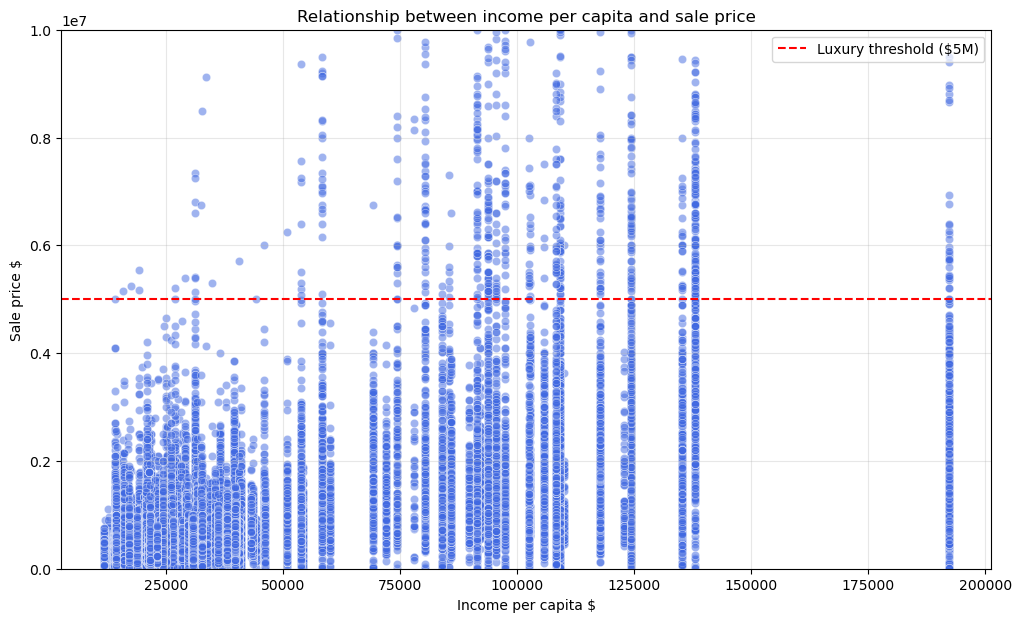

In [142]:
plt.figure(figsize = (12, 7))
sns.scatterplot(data = merged_dataset, x = 'income_per_cap', y ='sale_price', alpha = 0.5, color = 'royalblue')
#Add horizontal line which shows where is the $5 mln boundary
plt.axhline(y = 5000000, color='red', linestyle = '--', label = 'Luxury threshold ($5M)')
plt.title('Relationship between income per capita and sale price')
plt.xlabel('Income per capita $')
plt.ylabel('Sale price $')
plt.legend(loc = 'upper right')
plt.grid(True, alpha = 0.3)
plt.ylim(0, 10000000) 
plt.show()


The visualization clearly demonstrates the disconnect between local income levels and high-value property sales. The red dashed line at $5M shows the threshold where local purchasing power typically ends. While most transactions cluster below this line, we observe significant outliers even in mid-income areas. To reveal the true socio-economic correlation, we will remove these investment-driven outliers and normalize the data.

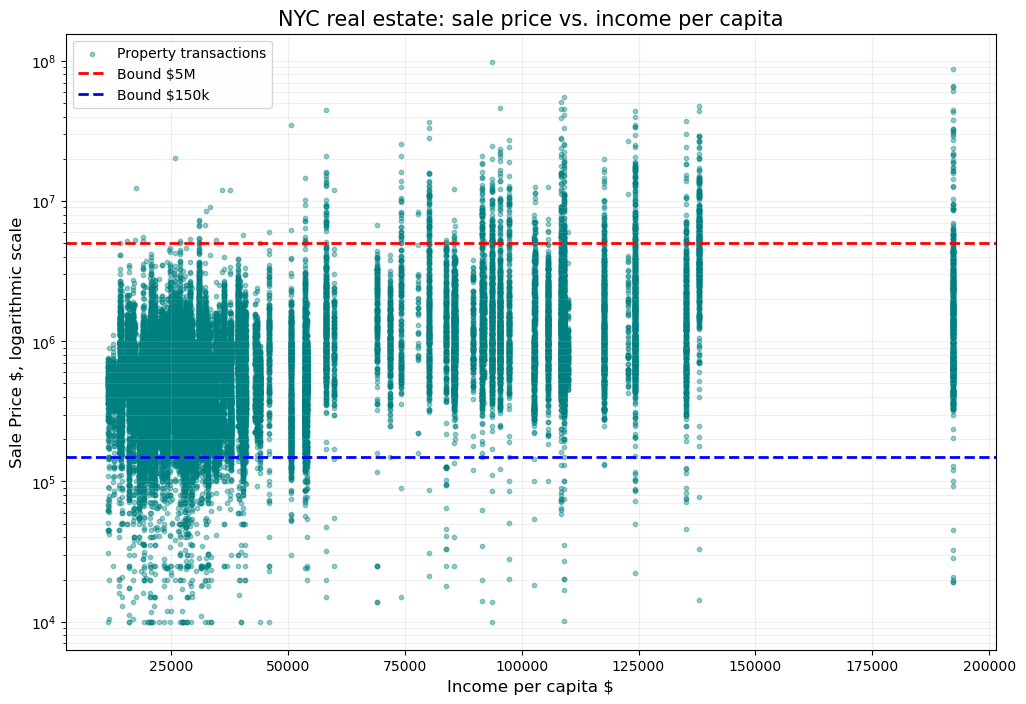

In [143]:
plt.figure(figsize=(12, 8))

plt.scatter(merged_dataset['income_per_cap'], merged_dataset['sale_price'], 
            alpha=0.4, color = 'teal', s = 10, label = 'Property transactions')

plt.yscale('log')
plt.axhline(5000000, color = 'red', linestyle = '--', linewidth = 2, label = 'Bound $5M')
plt.axhline(150000, color = 'blue', linestyle = '--', linewidth = 2, label = 'Bound $150k')
plt.title('NYC real estate: sale price vs. income per capita', fontsize = 15)
plt.xlabel('Income per capita $', fontsize = 12)
plt.ylabel('Sale Price $, logarithmic scale', fontsize = 12)
plt.legend()

plt.grid(True, which = "both", ls = "-", alpha = 0.2)
plt.show()

The scatter plot visualizes the relationship between local income levels and property prices across all five boroughs. The data is concentrated between the 150k and 5M thresholds, representing the vast majority of the NYC real estate market. \
Most transactions occur in neighborhoods where the income per cap is between 25k and 75k. We can observe a distinct vertical clustering at the higher end of the income scale (150k), where property prices consistently stay above the 1M. \
By using a logarithmic scale for the sale price we can clearly see the variance in lower priced properties that would otherwise be hidden, showing that price volatility exists at all income levels. The vertical alignment of data points is a direct result of the dataset structure, where multiple property transactions are linked to a single median income value for each census tract. This visualization confirms that while the neighborhood's socioeconomic status sets a clear baseline for property values, there is significant price diversity within each tract. The correlation proves that income is a primary driver of the area's market tier, yet it does not impose a fixed ceiling on individual property prices

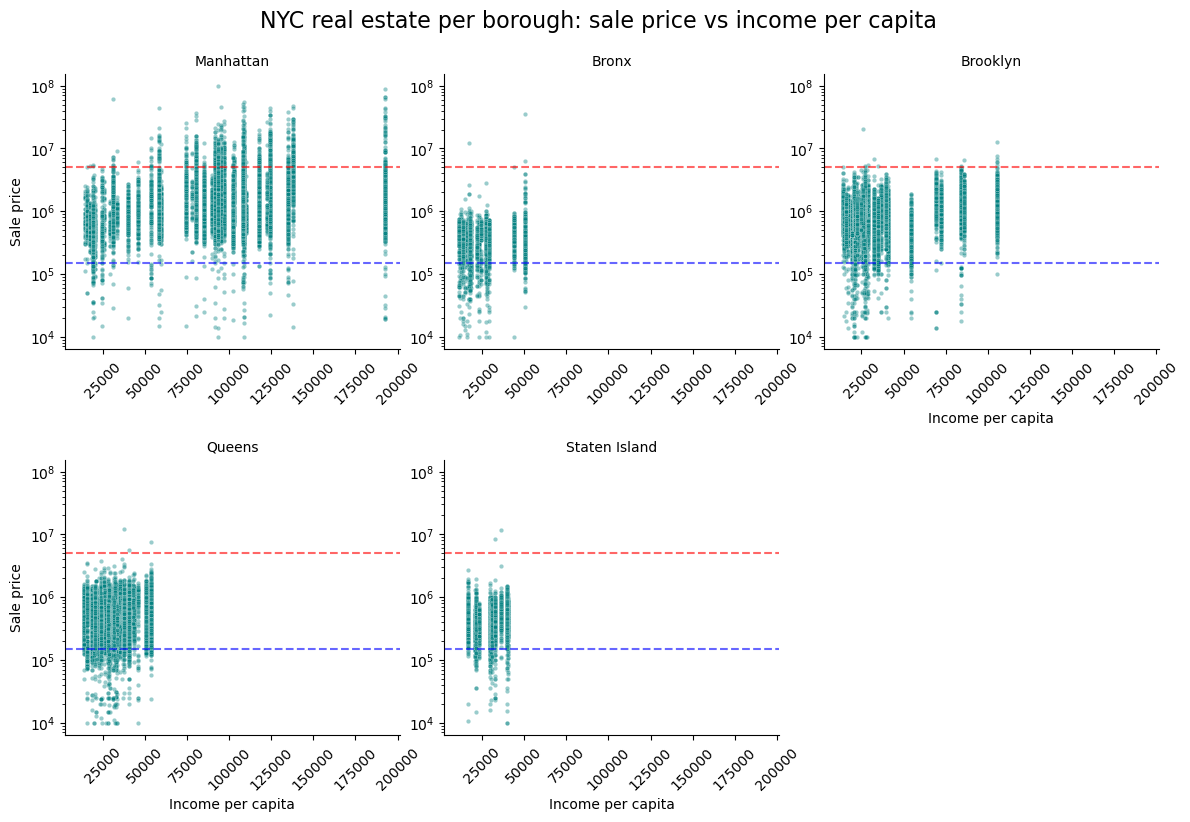

In [144]:
graphic_per_borough = sns.FacetGrid(merged_dataset, col = "borough", col_wrap = 3, height = 4, sharey = True)
graphic_per_borough.map(sns.scatterplot, "income_per_cap", "sale_price", alpha = 0.4, color = 'teal', s = 10)

for ax in graphic_per_borough.axes.flatten():
    ax.set_yscale('log')
    ax.axhline(5000000, color = 'red', linestyle = '--', alpha = 0.6, label = '$5M')
    ax.axhline(150000, color = 'blue', linestyle = '--', alpha=0.6, label = '$150k')
    ax.tick_params(axis = 'x', rotation = 45, labelbottom = True)
    ax.tick_params(axis= 'y', labelleft = True) 
    
graphic_per_borough.set_axis_labels("Income per capita", "Sale price")
graphic_per_borough.set_titles("{col_name}")
plt.subplots_adjust(top = 0.9, hspace = 0.4) 
graphic_per_borough.fig.suptitle('NYC real estate per borough: sale price vs income per capita', fontsize=16)

plt.show()

The plots examines the relationship between residential sales prices and local income levels across NYC’s five boroughs. The data is presented on a logarithmic scale to effectively visualize the vast price range, which spans from small transfers to multi-million dollar luxury investments. \
While the red and blue lines provide a general baseline for the entire city, it is important to recognize that the definition of an outlier varies significantly by borough. \
A price that is considered an extreme high-end outlier in the Bronx is a standard market price in Manhattan. *Affordable* home depends heavily on the local income levels shown on the X-axis. To achieve a more accurate socio-economic picture, we must evaluate these outliers individually for each neighborhood, as a one-size-fits-all approach does not account for the unique economic reality of each borough.

### Remove outliers on a macro level

By establishing these macro-level boundaries 100 000 - 5 000 000, we effectively filter out the market noise. These transactions are either too low to be residential sales or too high to be linked to local wages. We decided to remove these outliers in order not to skew our data analysis.

In [145]:
macro_dataset = merged_dataset[(merged_dataset['sale_price'] >= 100000) & 
                               (merged_dataset['sale_price'] <= 5000000)].copy()

In [146]:
len(macro_dataset)

50347

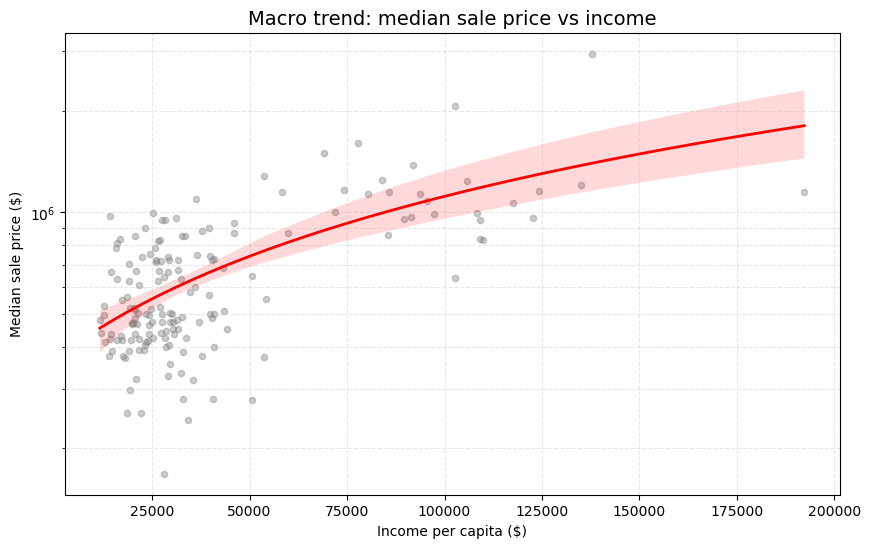

In [147]:
macro_trend = macro_dataset.groupby('income_per_cap')['sale_price'].median().reset_index()

plt.figure(figsize=(10, 6))
sns.regplot(data = macro_trend, x = 'income_per_cap', y = 'sale_price', 
            scatter_kws = {'alpha':0.4, 'color':'gray', 's':20}, 
            line_kws = {'color':'red', 'linewidth':2})

plt.yscale('log')
plt.title('Macro trend: median sale price vs income', fontsize=14)
plt.xlabel('Income per capita ($)')
plt.ylabel('Median sale price ($)')
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.show()


By aggregating the data into median sale prices per income level, we have removed individual transaction noise to reveal a strong, positive economic trend. The regression line confirms that as neighborhood wealth increases, property values scale accordingly. However, the dispersion of points around the trend line indicates that income is not the sole predictor of price. This serves as the perfect transition to our borough-specific analysis, where we will explore how these dynamics shift in different socio-economic environments.

### Remove outliers per borough

To ensure the socio-economic analysis reflects the reality of the average resident, we implemented a micro-level filtering approach.We defined unique boundaries for each borough based on their specific market dynamics.
While the macro analysis will gives us a general overview of New York City, it often masks the unique socio-economic characteristics of individual neighborhoods. To achieve higher precision, we implement a price range filter per borough. We recognize that a property price which is considered "normal" in Manhattan might be an extreme outlier in the Bronx. By setting manual thresholds for each borough, we ensure that our analysis is calibrated to the local resident's purchasing power. \
We want to isolate the actual residential market. By removing outliers - extreme expensive sales and very cheap (maybe non-market legal transfers) specifically for each borough, we can observe the relation between local wages and housing costs.

In [148]:
price_bounds = {
    'Manhattan': {'min': 150000, 'max': 6000000},
    'Bronx': {'min': 80000, 'max': 1200000},
    'Brooklyn': {'min': 120000, 'max': 5000000},
    'Queens': {'min': 90000, 'max': 2000000},
    'Staten Island': {'min': 100000, 'max': 1400000}
}

clean_data = []
for borough, bounds in price_bounds.items():
    subset = merged_dataset[merged_dataset['borough'] == borough]
    filtered = subset[(subset['sale_price'] >= bounds['min']) & 
                      (subset['sale_price'] <= bounds['max'])]
    clean_data.append(filtered)

micro_dataset = pd.concat(clean_data)


In [149]:
len(micro_dataset)

47343

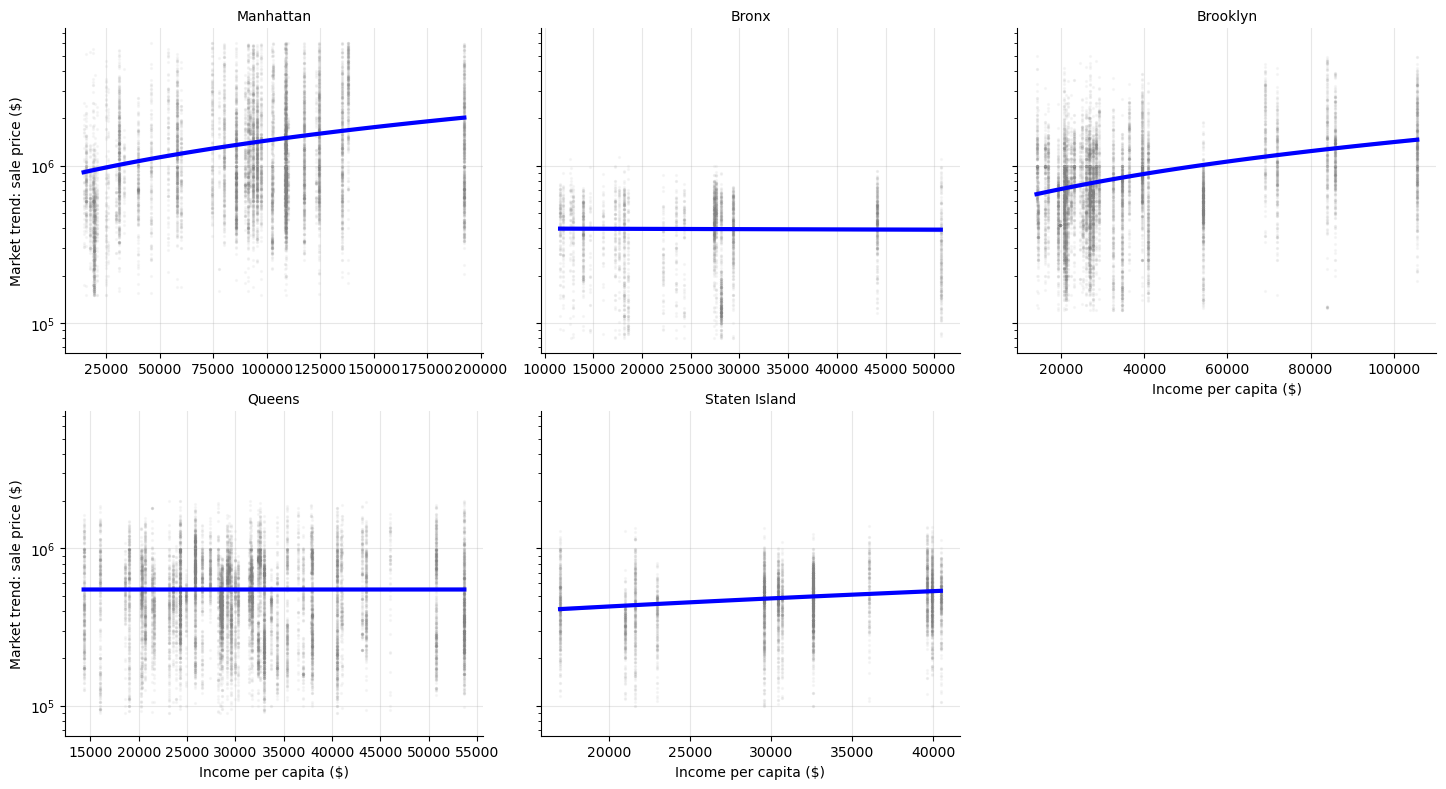

In [150]:
grid1 = sns.lmplot(
    data = micro_dataset, x = 'income_per_cap', y = 'sale_price', 
    col = 'borough', col_wrap = 3,
    scatter = True,
    scatter_kws = {'alpha': 0.05, 's': 2, 'color': 'gray'},
    line_kws = {'color': 'blue', 'linewidth': 3}, 
    ci = 95, 
    height = 4, aspect = 1.2,
    facet_kws={'sharex': False}
)

for ax in grid1.axes.flatten():
    ax.set_yscale('log')
    ax.grid(True, alpha = 0.3)

grid1.set_axis_labels("Income per capita ($)", "Market trend: sale price ($)")
grid1.set_titles("{col_name}")

plt.show()


The plot reveals a significant socio-economic divide in NYC. In Manhattan and Brooklyn property prices show a strong correlation with local income levels, indicating a market is driven by wealth accumulation. In contrast, the Bronx and Queens exhibit a flat trend, where property prices remain static regardless of income variations. The flat trend lines suggest that in these areas, property values are not driven by the purchasing power of the local residents. Instead prices are likely influenced by other underlying factors.  This could include square footage, the age of the building stock, or others.

In [151]:
macro_dataset['sale_price'].skew()

np.float64(2.519299577020826)

In statistics any value above 1.0 indicates a highly skewed distribution. This extreme result confirms that the dataset is dominated by high-value outliers that distort the mean and variance.

In [152]:
macro_dataset['log_sale_price'] = np.log10(merged_dataset['sale_price'])

We apply a logarithmic transformation $\log_{10}$ to the sale prices to normalize the distribution. Real estate data is right-skewed. By using logs, we reduce the impact of high-value variance and achieve a distribution closer to normal.

In [153]:
macro_dataset['log_sale_price'].skew()

np.float64(0.19595283056223065)

The comparison between the raw and transformed data highlights the necessity of our approach. The original distribution was right-skewed - **2.519**, making standard statistical tests unreliable. After applying the $\log_{10}$
 transformation, we achieved an almost perfect normal distribution with a skewness of 0.1959. This normalization allows us to accurately measure the impact of socio-economic factors on property values.

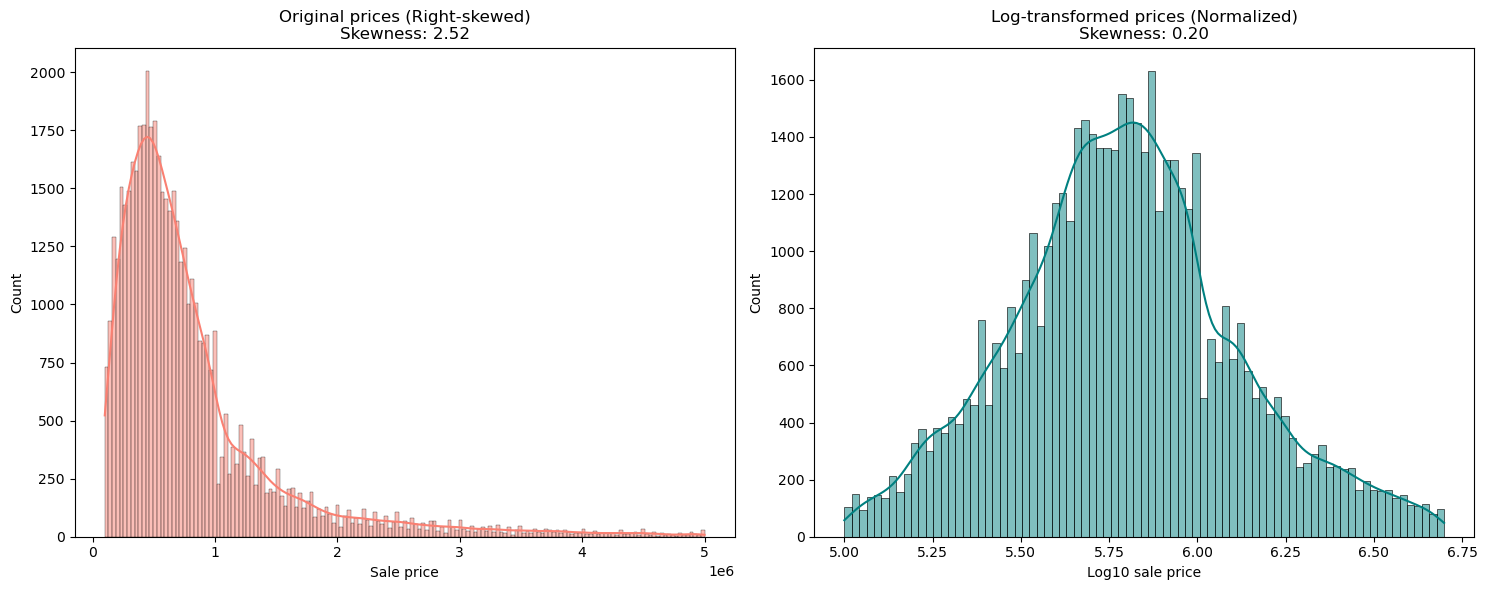

In [154]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#Right-Skewed - sale_price
sns.histplot(macro_dataset['sale_price'], kde = True, ax=ax1, color = 'salmon')
ax1.set_title('Original prices (Right-skewed)\nSkewness: {:.2f}'.format(macro_dataset['sale_price'].skew()))
ax1.set_xlabel('Sale price')

#Normalized prices
sns.histplot(macro_dataset['log_sale_price'], kde = True, ax = ax2, color = 'teal')
ax2.set_title('Log-transformed prices (Normalized)\nSkewness: {:.2f}'.format(macro_dataset['log_sale_price'].skew()))
ax2.set_xlabel('Log10 sale price')

plt.tight_layout()
plt.show()


### Group by region (census tract) and sale price

In [155]:
#Aggregating the data by tract
tract_analysis = macro_dataset.groupby('tract_id')[['log_sale_price', 'income_per_cap']].mean()

In [156]:
correlation_matrix = tract_analysis.corr()
correlation_matrix

,log_sale_price,income_per_cap
log_sale_price,1.00000,0.67541
income_per_cap,0.67541,1.00000


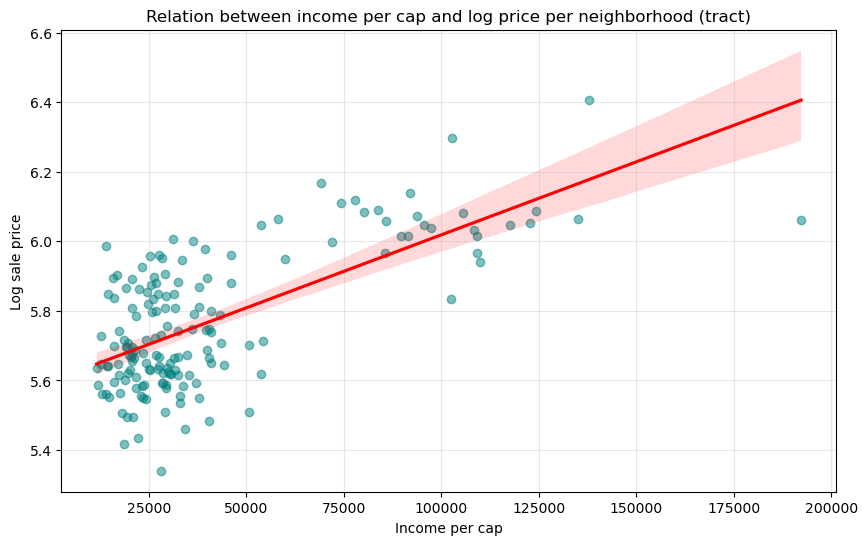

In [157]:
plt.figure(figsize = (10, 6))
sns.regplot(data = tract_analysis, x = 'income_per_cap', y = 'log_sale_price', 
            scatter_kws = {'alpha': 0.5, 'color': 'teal'}, line_kws = {'color': 'red'})

plt.title('Relation between income per cap and log price per neighborhood (tract)')
plt.xlabel('Income per cap')
plt.ylabel('Log sale price')
plt.grid(True, alpha = 0.3)
plt.show()

We can observe expensive regions with relatively lower incomes. The points located high above the regression line represent areas with very high real estate prices that cannot be explained directly by local income levels. These points represent areas where factors other than income influence the property prices. Despite that, the red regression line represents a stable trend: as median income increases, property prices rise proportionally.

## The impact of property area on sale price

We place a primary focus on **gross square footage** as the most critical determinant of property value. Our analysis aims to understand how physical size scales with price and where the market deviates from standard expectations. \
We calculate the **price per square foot (PPSF)** as a fundamental metric. Total sale price alone can be misleading due to varying property sizes and by standardizing the price relative to the area, we can objectively evaluate market value and identify which features (other than size) contribute to price premiums.\
We examine the interplay between various numerical variables. By analyzing the correlation matrix, we determine the strength of the relationship between physical attributes and the final sale price.

We generate a summary table of the variables sale price, gross quare feet, and income per cap, focusing on their distribution and range. By including specific percentiles from 1% to 99%, we can identify the typical boundaries for property prices and area size and identify extreme outliers. Comparing the mean and median values allows us to assess the skewness of the data, ensuring a solid foundation for further analysis and data cleaning

In [159]:
macro_stats = macro_dataset.dropna(subset=['gross_square_feet'])[['sale_price', 'gross_square_feet', 'income_per_cap']].describe(percentiles=[0.01, 0.05, 0.95, 0.99])
print(macro_stats)

         sale_price  gross_square_feet  income_per_cap
count  2.489200e+04       24892.000000    23983.000000
mean   7.030785e+05        1861.610638    30342.951591
std    4.867391e+05         780.478671    12325.441351
min    1.000000e+05         240.000000    11577.000000
1%     1.500000e+05         720.000000    12706.000000
5%     2.367269e+05         968.000000    16003.400000
50%    5.800000e+05        1690.000000    28617.000000
95%    1.525000e+06        3300.000000    53683.000000
99%    2.749090e+06        4200.000000    83851.000000
max    5.000000e+06       30000.000000   192303.000000


The significant gap between the 99th percentile and the maximum values for both sale price and area indicates the presence of extreme outliers that require further cleaning

We create a new metric price per square foot (PPSF), to standardize property values and enable a more accurate comparison across different sizes and market segments.

In [194]:
#remove properties without gross square feet
properties_with_area = macro_dataset.dropna(subset=['gross_square_feet']).copy()

In [252]:
properties_with_area['price_per_sqft'] = properties_with_area['sale_price'] / properties_with_area['gross_square_feet']

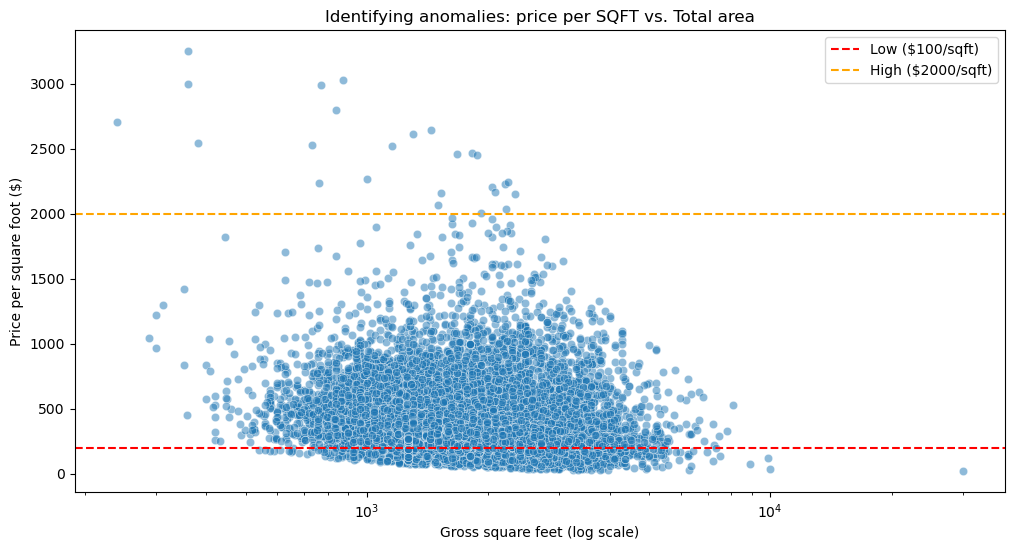

In [203]:
plt.figure(figsize = (12, 6))
sns.scatterplot(data = properties_with_area, x = 'gross_square_feet', y = 'price_per_sqft', alpha = 0.5)

plt.axhline(200, color = 'red', linestyle = '--', label = 'Low ($100/sqft)')
plt.axhline(2000, color = 'orange', linestyle = '--', label = 'High ($2000/sqft)')

plt.xscale('log')
plt.title('Identifying аnomalies: price per SQFT vs. Total area')
plt.xlabel('Gross square feet (log scale)')
plt.ylabel('Price per square foot ($)')
plt.legend()
plt.show()

By visualizing the **PPSF** against the **gross square footage**, we identified several significant anomalies that would have skewed the regression analysis. These anomalies fall into two main categories:
* **Non-market transactions** - properties with an extremely low PPSF under $200/sqft. These often represent administrative transfers, sales between family members, or dilapidated structures that don't reflect the actual real estate market value.
* **Industrial/commercial outliers** - large properties above 8,000–10,000 sqft often showed disproportionately low prices. These may to be industrial warehouses or special billing lots rather than typical residential dwellings.

In [201]:
low_anomalies = properties_with_area[properties_with_area['price_per_sqft'] < 200].copy()

In [165]:
high_anomalies = properties_with_area[properties_with_area['price_per_sqft'] > 2500].copy()

In [202]:
len(low_anomalies), len(high_anomalies)

(3267, 11)

In [204]:
print(low_anomalies[['borough', 'building_class_category', 'gross_square_feet', 'sale_price', 'price_per_sqft']].sort_values('gross_square_feet', ascending=False).head(10))
print(high_anomalies[['borough', 'building_class_category', 'gross_square_feet', 'sale_price', 'price_per_sqft']].sort_values('gross_square_feet', ascending=False).head(10))

             borough        building_class_category  gross_square_feet  \
23745       Brooklyn  11 Special Condo Billing Lots            30000.0   
33925         Queens      03 Three Family Dwellings            10000.0   
50735  Staten Island        02 Two Family Dwellings             9872.0   
20570       Brooklyn      03 Three Family Dwellings             8911.0   
51163  Staten Island        01 One Family Dwellings             7500.0   
34718         Queens        02 Two Family Dwellings             7350.0   
17139          Bronx        02 Two Family Dwellings             7215.0   
50683  Staten Island        01 One Family Dwellings             6976.0   
49105  Staten Island        01 One Family Dwellings             6440.0   
27045       Brooklyn        01 One Family Dwellings             6367.0   

       sale_price  price_per_sqft  
23745    600000.0       20.000000  
33925    350001.0       35.000100  
50735   1204000.0      121.961102  
20570    700000.0       78.554595  
51163

In [205]:
clean_macro_data = properties_with_area[
    (properties_with_area['gross_square_feet'] > 250) & 
    (properties_with_area['gross_square_feet'] < 8000) &
    (properties_with_area['price_per_sqft'] >= 200) &
    (properties_with_area['price_per_sqft'] <= 2500)
].copy()


In [206]:
len(properties_with_area) - len(clean_macro_data)

3279

We focused on properties with valid area. We remove outliers and anomalies (PPST < 200 dollars and > 2500 dollars, and area 250-8000 sqft range), ensuring the regression model represents the typical NYC residential market.

## Market segmentation 
## Houses vs. Apartments

We aim to analyse how gross square feet affects the market value across different property types. New York City's real estate market is highly diverse, and we expect that residential houses and apartments might follow different pricing logics. \
we will segment the dataset into two main categories:
* Houses
* Apartments

We will calculate the correlation coefficients for each group separately to determine which segment is more sensitive to physical space and whether factors like location prestige create a different impact on their respective prices.

In [229]:
houses = clean_macro_data[clean_macro_data['building_class_category'].str.contains('01|02|03')].copy()

In [233]:
apartments = clean_macro_data[clean_macro_data['building_class_category'].str.contains('Coops|Condos|04|16|11')].copy()

In [234]:
len(houses), len(apartments)

(20608, 1001)

In [235]:
#correlation
houses_corr = houses['gross_square_feet'].corr(houses['sale_price'])

In [236]:
houses_corr

np.float64(0.5763095376918493)

Houses show a moderate to strong positive correlation. This confirms that for standalone homes, gross square footage is a consistent and reliable driver of market value, as more living space generally commands a higher price premium.

In [237]:
houses['total_property_size'] = houses['gross_square_feet'] + houses['land_square_feet']

In [238]:
combined_corr = houses['total_property_size'].corr(houses['sale_price'])

In [242]:
print(f"Correlation gross square feet + land vs. Price: {combined_corr:.3f}")
print(f"Only gross square feet: {houses['gross_square_feet'].corr(houses['sale_price']):.3f}")

Correlation gross square feet + land vs. Price: 0.274
Only gross square feet: 0.576


We tested whether combining building size and land area (total_property_size) would provide a better price predictor. Interestingly, the correlation dropped significantly from 0.571 to 0.274. This proves that in the NYC market, gross square footage is a much stronger driver of value than land area. This highlights the urban nature of the market, where indoor utility outweighs outdoor space.

In [240]:
apartments_corr = apartments['gross_square_feet'].corr(apartments['sale_price'])

In [241]:
apartments_corr

np.float64(0.8013231272759742)

Due to the high volume of missing area data in the original registry, our cleaned sample size was reduced to only 1,001 records. This strong correlation suggests that for properties with transparent reporting, size is the dominant price factor, but the small sample size introduces a selection bias that may not fully represent the broader NYC apartment market.

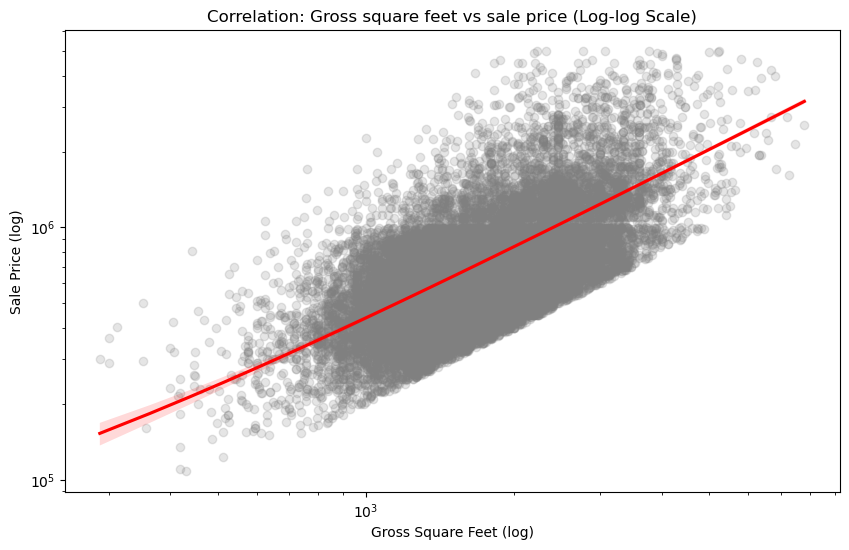

In [243]:
plt.figure(figsize=(10, 6))
sns.regplot(data = clean_macro_data, x = 'gross_square_feet', y = 'sale_price', 
            scatter_kws = {'alpha': 0.2, 'color': 'gray'}, line_kws = {'color':'red'})

plt.xscale('log')
plt.yscale('log')
plt.title('Correlation: Gross square feet vs sale price (Log-log Scale)')
plt.xlabel('Gross Square Feet (log)')
plt.ylabel('Sale Price (log)')
plt.show()


The regression line on this log-log plot demonstrates a steady and consistent increase in property price as square footage grows. By utilizing a logarithmic scale for both axes, we have minimized the distortion caused by extreme values and revealed a clearer linear relationship within the typical residential market. \
After applying our filters PPSF between 200 - 2500 dollars and area between 250 - 8000 sqft, the data points form a dense cluster. This represents the middle market of NYC, where the relationship between size and price is most stable.\
Even with a strong correlation, we observe a significant vertical spread. For instance, properties with an identical area of 1000 sqft can show price differences of several million dollars.
The visualization confirms that while our data cleaning has significantly improved the model's reliability, real estate pricing in a complex urban environment like New York City remains a multi-dimensional problem where location often dictates the premium paid per square foot.

### Relationship between income and property size

Hypothesis testing 

$H_0$: There is no correlation between neighborhood income and property size ($\rho = 0$) \
$H_1$: There is a significant positive correlation between neighborhood income and property size ($\rho > 0$)


In [249]:
income_area_corr = clean_macro_data['income_per_cap'].corr(clean_macro_data['gross_square_feet'])
print(f"Correlation between income and area: {income_area_corr:.3f}")

Correlation between income and area: 0.036


The correlation coefficient is $r$ = 0.036. Since $r \approx 0$, we fail to reject the null hypothesis, concluding that there is no meaningful linear relationship between the two variables.

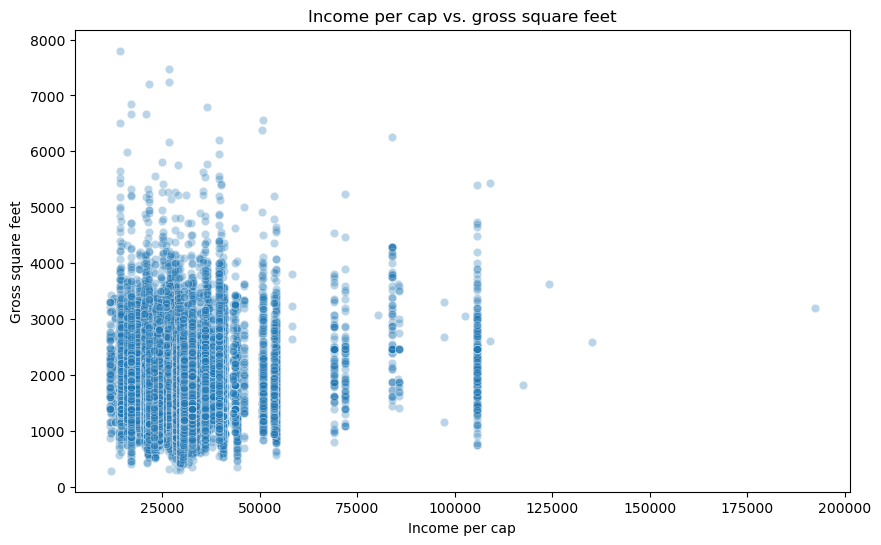

In [251]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data = clean_macro_data, x = 'income_per_cap', y = 'gross_square_feet', alpha = 0.3)
plt.title('Income per cap vs. gross square feet')
plt.xlabel('Income per cap')
plt.ylabel('Gross square feet')
plt.show()


The scatter plot shows a vertical distribution of data points, indicating that property size remains relatively consistent across different income levels. There is no observable upward trend, which suggests that neighborhood income per cap is not a significant predictor of gross square footage. In the NYC market, space appears to be constrained by urban density rather than income, meaning that wealthier areas do not necessarily feature larger residential units.